# Машинное обучение, ФКН ВШЭ

# Практическое задание 9. Несбалансированные задачи

## Общая информация
Дата выдачи: 01.03.2026

Мягкий дедлайн: 15.03.2026 23:59 MSK

Жесткий дедлайн: 22.03.2026 23:59 MSK

## Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.

## Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-xx-Username.ipynb

Username — ваша фамилия и имя на латинице именно в таком порядке

## О задании

В этом задании мы разберем основные техники работы в задачах, где один из классов занимает существенно меньшую долю выборки, чем остальные. Для простоты мы обойдемся бинарной задачей, тем не менее, во многом данные методы можно перенести и на задачи с б**о**льшим числом классов. Кроме того, вы получите очередной бесценный опыт исследования случайной библиотеки случайных индусов с нуля.

In [1]:
import numpy as np
import pandas as pd
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

from tqdm.auto import tqdm

**Задание -1 (1 балл)**. EDA

В качестве данных для нашей работы возьмем выложенный на kaggle датасет транзакций, в котором нужно выискивать мошеннические проводки: [клик](https://www.kaggle.com/mlg-ulb/creditcardfraud). Данная задача по определению подходит под несбалансированную, что можно сказать даже без наличия каких-либо данных (понятно, что среди всех транзакций клиентов очень малая часть будет мошеннической).

Загрузим данные, проведем некоторые классические манипуляции.

In [2]:
df = pd.read_csv('/kaggle/input/datasets/shaykoaleksandr/credit-card-dataset/creditcard.csv')

In [3]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


Наши данные были анонимизированы. Мы имеем 30 признаков, из которых 28 - это результаты PCA-преобразования на исходном датасете. Еще 2 признака представляют собой время в секундах, прошедшее с момента первой транзакции в датасете, и размер транзакции. Скажите, какова доля положительных объектов в выборке?

In [4]:
df[df['Class'] == 1].shape[0]/df.shape[0]

0.001727485630620034

Начнем с обработки времени. Секунды сами по себе не несут большой информации о зависимостях в данных, попробуйте по ним создать признаки 'час' (от 0 до 23) и 'день' (от 0 до ...) в аналогичной манере (принимая первый объект выборки за начальную точку). Сколько дней покрывают данные?

In [5]:
df['hour'] = (df['Time']//3600)%24
df['day'] = df['Time']//(3600 * 24)

In [6]:
df['day'].max()

1.0

То есть наши данные покрывают 2 дня

Постройте следующие графики:

1. Распределение числа транзакций по каждому часу (line-plot).
2. Распределение доли мошеннических транзакций по каждому часу (line-plot)
3. То же самое для дней (здесь можно использовать bar-plot, так как дней должно быть немного).

Какие выводы можно сделать из графиков? На ваш взгляд, как можно связать полученные нами часы с реальными часами в сутках?

In [7]:
frauds = df[df['Class'] == 1]

In [8]:
oper_frauds_hour = frauds.groupby(frauds['hour'])['Amount'].count()
oper_total_hour = df.groupby(df['hour'])['Amount'].count()
frauds_part_hour = oper_frauds_hour/oper_total_hour

In [9]:
oper_frauds_day = frauds.groupby(frauds['day'])['Amount'].count()
oper_total_day = df.groupby(df['day'])['Amount'].count()
frauds_part_day = oper_frauds_day/oper_total_day

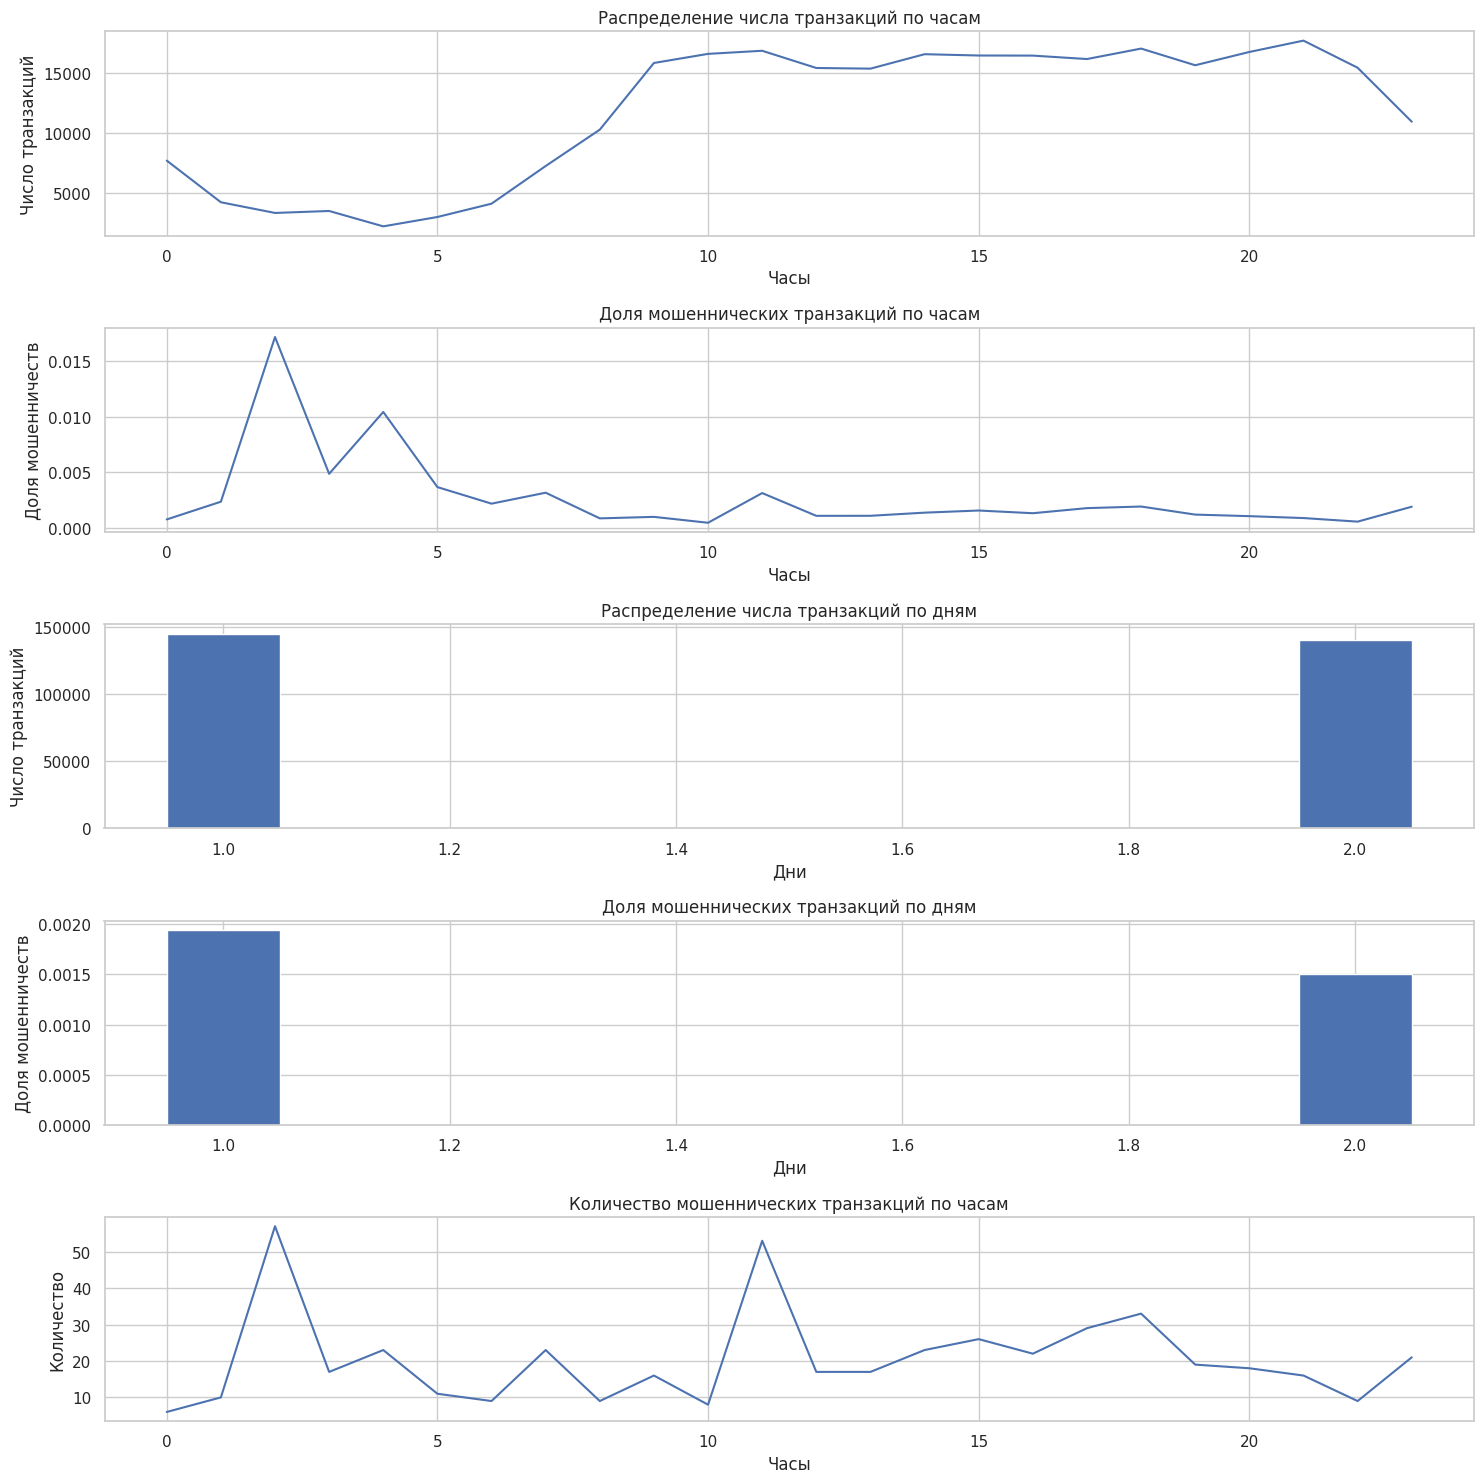

In [10]:
days = [1, 2]

fig, axes = plt.subplots(5, 1, figsize=(15, 15))

axes[0].plot(oper_total_hour)
axes[0].set_title('Распределение числа транзакций по часам')
axes[0].set_ylabel('Число транзакций')
axes[0].set_xlabel('Часы')

axes[1].plot(frauds_part_hour)
axes[1].set_title('Доля мошеннических транзакций по часам')
axes[1].set_ylabel('Доля мошенничеств')
axes[1].set_xlabel('Часы')

axes[2].bar(oper_total_day.index + 1, oper_total_day, width = 0.1)
axes[2].set_title('Распределение числа транзакций по дням')
axes[2].set_ylabel('Число транзакций')
axes[2].set_xlabel('Дни')

axes[3].bar(frauds_part_day.index + 1, frauds_part_day, width = 0.1)
axes[3].set_title('Доля мошеннических транзакций по дням')
axes[3].set_ylabel('Доля мошенничеств')
axes[3].set_xlabel('Дни')

axes[4].plot(oper_frauds_hour)
axes[4].set_title('Количество мошеннических транзакций по часам')
axes[4].set_ylabel('Количество')
axes[4].set_xlabel('Часы')


plt.tight_layout()
plt.show()

Судя по графикам, часы на самом деле довольно хорошо соотносятся с часами суток, поскольку ночью очевидно транзакций будет мало, а начиная с 10 утра, как только все проснутся, позавтракают, люди начинают совершать многочисленные покупки. При этом, после 8 вечера все уже отдыхают и готовятся ко сну, поэтому число транзакций сильно снижается. Также судя по количеству транзакций по дням, мы можем предположить, что это либо два выходных, либо два соседних будних дня, поскольку если бы дни были на стыке будних и выходных, то скорее всего в один из дней транзакций было бы больше (например, скорее всего, в воскресенье люди меньше покупают, чем в понедельник, поскольку в воскресенье все понимают, что завтра рабочий день и восстанавливаются от большого числа событий (тусовок, работы) скорее дома, чем где-то). Причем скорее всего это все-таки будние дни, потому что в выходные люди часто отдыхают и ночью, а потом просыпаются намного позже 10 утра.

Последний вывод, для которого понадобился 5 график состоит в том, что мошенники атакуют людей ночью, когда все спят и никто не может отследить какие-то подозрительные списания, а также утром, когда, видимо, люди еще не успели проснуться

С анонимизированными признаками вряд ли можно придумать что-то интересное. Попробуйте (например, с помощью корреляции?) выбрать несколько наиболее важных признаков и поглядеть на различия в их распределении для разных классов.

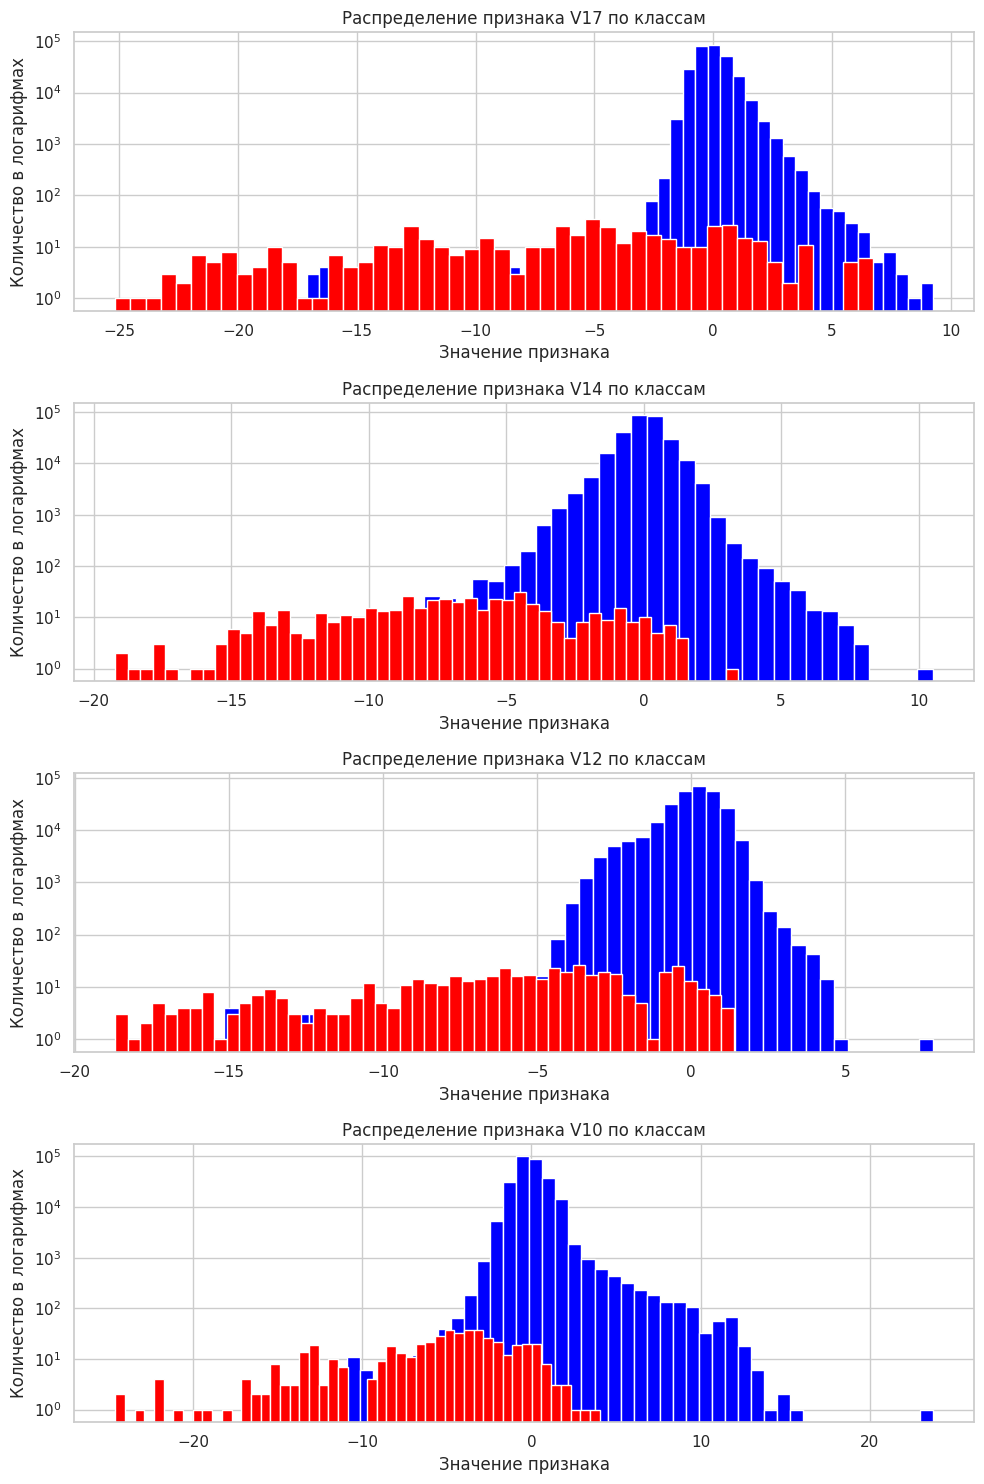

In [11]:
corr_with_frauds = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)
top_4_corrs = corr_with_frauds.head(4).index.to_list()
fig, axes = plt.subplots(4, 1, figsize=(10, 15))
for i in range(len(top_4_corrs)):
    axes[i].hist(df[df['Class'] == 0][top_4_corrs[i]], bins=50, color='blue')
    axes[i].hist(df[df['Class'] == 1][top_4_corrs[i]], bins=50, color='red')
    axes[i].set_yscale('log')
    axes[i].set_title(f'Распределение признака {top_4_corrs[i]} по классам')
    axes[i].set_ylabel('Количество в логарифмах')
    axes[i].set_xlabel('Значение признака')
plt.tight_layout()
plt.show()

Как мы видим, мошенничества сконцентрированны в отрицательных значениях по нашим PCA векторам. Можно предположить, что в оригинальном датасете был, например, признак время от предыдущей сделки по этой карте. И вектор V17 вытянут вдоль этого признака. Тогда если времени прошло мало между сделками, то скорее всего это мошенник, который скупает все подряд по украденной карточке. А если времени прошло обычно, то это обычный человек (логично). Ну, в общем, для мошеннических сделок все будет экстремально мало

Теперь давайте разделим данные. Отделите хронологически последние 20% транзакций и поделите их пополам (также хронологически, т.е. без перемешивания) на валидационные и тестовые. Это разбиение не совсем корректно (как можно было заметить, мошеннические транзакции имеют разное распределение во времени - по-хорошему, нам стоило бы выделить целые сутки записей как под валидацию, так и под тест), тем не менее, мы не сможем получить больше данных для адекватного контроля, поэтому обойдемся этим. 

In [12]:
#your code here
total_transactions = len(df)
quantile_80 = int(total_transactions * 0.8)
quantile_90 = int(total_transactions * 0.9)
train_df = df.iloc[:quantile_80]
val_df = df.iloc[quantile_80:quantile_90]
test_df = df.iloc[quantile_90:]

y_train = train_df['Class']
X_train = train_df.drop(columns=['Class', 'Time'])

y_val = val_df['Class']
X_val = val_df.drop(columns=['Class', 'Time'])

y_test = test_df['Class']
X_test = test_df.drop(columns=['Class', 'Time'])

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Часть 1. Несбалансированная классификация.

**Задание 0. (1 балл)**: перед началом работы давайте поговорим о том, как мы будем оценивать качество. Классические метрики для качества классификации чаще всего 'ломаются' на задачах с сильным перекосом. Чему будет равно значение accuracy для наивного предсказания (= мажорный класс для каждого объекта)? (можете не отвечать, просто подумайте)

Из курса МО-1 вам уже известно, что мы можем использовать в таких задачах `AUC-PR` и получать адекватные показатели. Можно сказать, что `AUC-PR` представляет собой матожидание `precision` по распределению, заданному выигрышем в `recall` при смене порога. 

In [14]:
#your code here
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, auc

model = LogisticRegression(class_weight='balanced', max_iter=1000, solver='lbfgs', penalty='l2', C=1.0)
model.fit(X_train, y_train)

y_val_probs = model.predict_proba(X_val)[:, 1]

precision_val, recall_val, thresholds_val = precision_recall_curve(y_val, y_val_probs)
pr_auc_val = auc(recall_val, precision_val)

target_id = np.argmin(np.abs(recall_val - 0.9))
optimal_threshold_val = thresholds_val[target_id - 1]
optimal_precision_val = precision_val[target_id]
optimal_recall_val = recall_val[target_id]

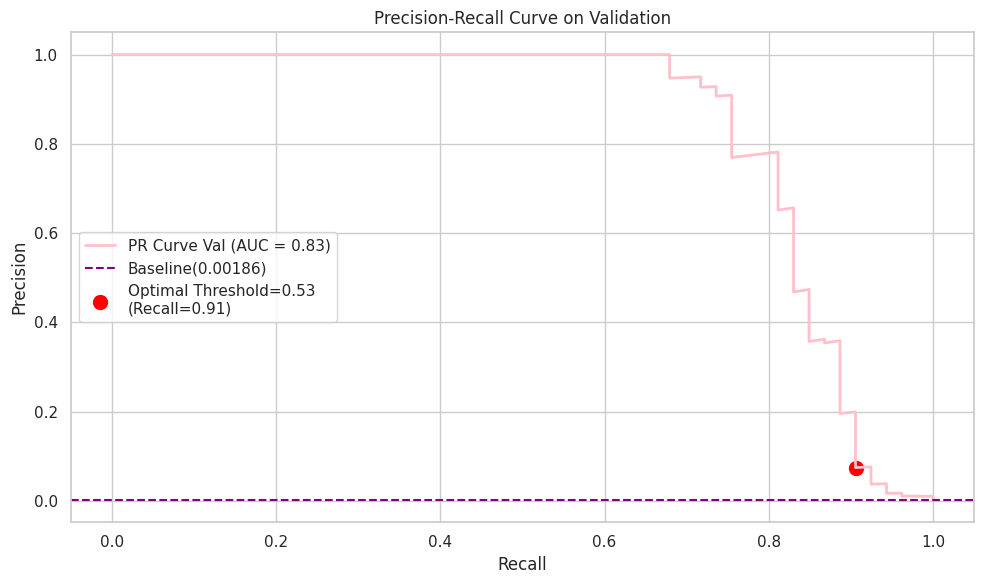

In [15]:
plt.figure(figsize=(10, 6))

plt.plot(recall_val, precision_val, color='pink', lw=2, label=f'PR Curve Val (AUC = {pr_auc_val:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve on Validation')

baseline_val = y_val.mean()
plt.axhline(y=baseline_val, color='purple', linestyle='--', label=f'Baseline({baseline_val:.5f})')

plt.scatter(
    [optimal_recall_val],
    [optimal_precision_val],
    color='red',
    s=100,
    label=f'Optimal Threshold={optimal_threshold_val:.2f}\n(Recall={optimal_recall_val:.2f})'
)

plt.legend()
plt.tight_layout()
plt.show()

---
Теперь построим PR-кривую для теста

In [16]:
y_test_probs = model.predict_proba(X_test)[:, 1]

precision_test, recall_test, thresholds_test = precision_recall_curve(y_test, y_test_probs)
pr_auc_test = auc(recall_test, precision_test)

In [17]:
from sklearn.metrics import precision_score, recall_score
y_test_pred_optimal = (y_test_probs >= optimal_threshold_val).astype(int)

point_precision_test = precision_score(y_test, y_test_pred_optimal)
point_recall_test = recall_score(y_test, y_test_pred_optimal)

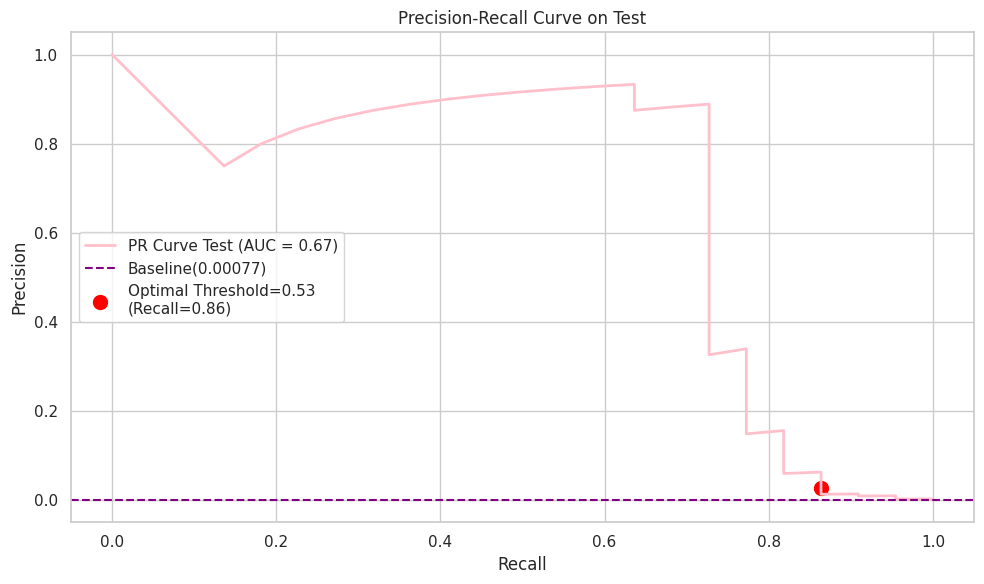

In [18]:
plt.figure(figsize=(10, 6))

plt.plot(recall_test, precision_test, color='pink', lw=2, label=f'PR Curve Test (AUC = {pr_auc_test:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve on Test')

baseline_test = y_test.mean()
plt.axhline(y=baseline_test, color='purple', linestyle='--', label=f'Baseline({baseline_test:.5f})')

plt.scatter(
    [point_recall_test],
    [point_precision_test],
    color='red',
    s=100,
    label=f'Optimal Threshold={optimal_threshold_val:.2f}\n(Recall={point_recall_test:.2f})'
)

plt.legend()
plt.tight_layout()
plt.show()

Тем не менее, существуют и другие, не менее интересные метрики. Одной из таких метрик является коэффициент Каппа Коэна, представляющий собой нормализованную `accuracy`:

$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

Данная метрика служит в качестве меры согласованности между двумя независимыми предсказателями, но ничего не знает про 'верные' и 'предсказанные' метки (в отличие от многих других метрик машинного обучения). Здесь $p_o$ - доля согласованных предсказаний, а $p_e$ - доля согласованных предсказаний, которая могла бы получиться при случайных ответах предсказателей. В нашем случае это работает так:

• В качестве $p_o$ берем accuracy

• В качестве $p_e$ примем следующую величину - вероятность случайного соглашения позитивных ответов (произведение долей позитивных ответов в обоих предсказаниях) плюс вероятность случайного соглашения негативных ответов (произведение долей негативных ответов в обоих предсказаниях)

Метрика принимает значения от -1 до 1, где 1 - полная согласованность, 0 - согласованность на уровне рандома, -1 - совсем плохо. Как уже говорилось, метрика не различает 'верные' и 'предсказанные' метки, поэтому является симметричной (можете использовать это для отладки):

In [19]:
#your code here
from sklearn.metrics import cohen_kappa_score, accuracy_score

kappa = cohen_kappa_score(y_test, y_test_pred_optimal)

acc = accuracy_score(y_test, y_test_pred_optimal)

print(f'Accuracy: {acc:.3f}')
print(f"Cohen's Kappa: {kappa:.3f}")

Accuracy: 0.977
Cohen's Kappa: 0.053


---
Просто для сравнения считаем accuracy. Accuracy остается высокой, потому что у нас ну очень много объектов с уверенностью ниже порога. А вот Каппа Кохена низкая, потому что мы таргетим recall 0.9, следовательно, модель чаще назначает класс равный 1, следовательно, у нее больше вероятность чисто статистически попасть в плюс. Соответственно, даже то, что наша модель там может и вправду различать положительный и отрицательный классы и назначать плюсы лучше, чем рандомно, не даст большого прироста, поскольку почти все плюсы мы назовем и так рандомно. Поэтому, чтобы каппу увеличить, нам надо было бы увеличить трешхолд. В таком случае модель бы редко говорила плюсы, а значит, что рандомно очень маленькая вероятность попасть в них. И при этом, так как сама модель умеет очень хорошо предсказывать плюсы, то каппа будет выше.

---
Попробуем теперь найти наилучший порог с точки зрения Каппы Кохена. Судя по нашим выводам, он должен быть довольно высоким, чтобы метрика считала нашу модель 'умной'

In [20]:
kappa_scores = []

for t in thresholds_val:
    y_val_pred = (y_val_probs >= t).astype(int)
    kappa_scores.append(cohen_kappa_score(y_val, y_val_pred))
    
best_id_kappa = np.argmax(kappa_scores)
thresh_optim_kappa = thresholds_val[best_id_kappa]

y_test_pred_opt_kappa = (y_test_probs >= thresh_optim_kappa).astype(int)
kappa_opt = cohen_kappa_score(y_test, y_test_pred_opt_kappa)

acc_opt_kappa = accuracy_score(y_test, y_test_pred_opt_kappa)

print(f'Accuracy: {acc_opt_kappa:.3f}')
print(f"Cohen's Kappa: {kappa_opt:.3f}")

Accuracy: 1.000
Cohen's Kappa: 0.780


Еще одной метрикой в такой задаче служит коэффициент корреляции Мэтьюза, выражающийся в терминах матрицы ошибок следующим образом:

$$\text{MCC} = \frac{TP\times TN - FP \times FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$$ 

Метрика принимает значения от -1 до 1, интерпретируемые аналогичным образом. 

In [21]:
#your code here
from sklearn.metrics import matthews_corrcoef

mcc_score_recall = matthews_corrcoef(y_test, y_test_pred_optimal)

mcc_score_kappa = matthews_corrcoef(y_test, y_test_pred_opt_kappa)

print(f'MCC with recall 0.9: {mcc_score_recall:.2f}')
print(f'MCC with best kappa threshold: {mcc_score_kappa:.2f}')

MCC with recall 0.9: 0.15
MCC with best kappa threshold: 0.78


---
Ну и попробуем найти лучший порог с точки зрения коэффициента корреляции Мэтьюза

In [22]:
matthews_scores = []

for t in thresholds_val:
    y_val_pred = (y_val_probs >= t).astype(int)
    matthews_scores.append(matthews_corrcoef(y_val, y_val_pred))
    
best_id_matcor = np.argmax(matthews_scores)
thresh_optim_mat = thresholds_val[best_id_matcor]

y_test_pred_opt_mat = (y_test_probs >= thresh_optim_mat).astype(int)
mattcor_opt = matthews_corrcoef(y_test, y_test_pred_opt_mat)

print(f'Matthews coeff score: {mattcor_opt:.3f}')

Matthews coeff score: 0.782


---

Как мы видим, на самом деле не очень сильно отличается от тех результатов, где мы подбирали порог по каппе

---

Обратите внимание, что эти метрики вычисляются на бинаризованных предсказаниях, поэтому может иметь смысл дополнительная настройка порога бинаризации.

Давайте проверим, что наши метрики действительно подходят под задачу. Вычислите их значения для наивного предсказания (aka мажорный класс для всех объектов):

In [23]:
y_stup_pred = np.zeros_like(y_val)

acc_stup = accuracy_score(y_val, y_stup_pred)
kappa_stup = cohen_kappa_score(y_val, y_stup_pred)
recall_stup = recall_score(y_val, y_stup_pred, zero_division=0)

print(f'Naive Accuracy: {acc_stup:.5f}')
print(f'Naive Kappa: {kappa_stup:.5f}')
print(f'Naive Recall: {recall_stup:.5f}')

Naive Accuracy: 0.99814
Naive Kappa: 0.00000
Naive Recall: 0.00000


---
Ну, как мы видим, наивная модель и вправду дает нулевые значения по метрикам, что говорит о том, что они и вправду учитывают несбалансированность классов и банят модели, которые просто отдают предпочтения мажорному классу

---
А ПОЧЕМУ ЭТОГО НЕЛЬЗЯ БЫЛО НАПИСАТЬ В НАЧАЛЕ? Вот зачем были ячейки с #your code??

Давайте запустим бейзлайн-решение для нашей задачи. С чего же начнем? Возьмите `catboost` и обучите его классификатор на наших данных (используйте все признаки). Вычислите значения всех метрик на тестовой части, для контроля переобучения используйте валидационную (здесь и далее везде, где фигурирует `catboost`). 

Снова сформируем наши иксы, потому что до этого они были отскалированны

In [24]:
X_train = train_df.drop(columns=['Class', 'Time'])

X_val = val_df.drop(columns=['Class', 'Time'])

X_test = test_df.drop(columns=['Class', 'Time'])

In [25]:
from catboost import CatBoostClassifier

In [26]:
#your code here

model_base = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='PRAUC',
    early_stopping_rounds=50,
    verbose=100, 
    random_seed=67
)

model_base.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True
)

0:	learn: 0.6841728	test: 0.7311099	best: 0.7311099 (0)	total: 108ms	remaining: 1m 48s
100:	learn: 0.9055916	test: 0.8535858	best: 0.8535858 (100)	total: 6.41s	remaining: 57.1s
200:	learn: 0.9271567	test: 0.8568591	best: 0.8606575 (155)	total: 12.9s	remaining: 51.4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8606574687
bestIteration = 155

Shrink model to first 156 iterations.


In [27]:
y_val_probs = model_base.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_val_probs)
id_target_recall = np.argmin(np.abs(recall - 0.9))
optimal_threshold = thresholds[id_target_recall]

print(f'Подобранный нами порог для достижения Recall = 0.9 на валидации: {optimal_threshold:.3f}\n')

y_test_probs = model_base.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_probs >= optimal_threshold).astype(int)

test_kappa = cohen_kappa_score(y_test, y_test_pred)
test_matt = matthews_corrcoef(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)


print(f'Наши метрики на тесте полученные через подбор порога (threshold = {optimal_threshold:.4f}) по значению Recall: \n')
print(f'MCC on test: {test_matt:.3f}')
print(f'Recall on test: {test_recall:.3f}')
print(f"Cohen's Kappa on test: {test_kappa:.3f}")
print(50*'-')

kappa_scores = []

for t in thresholds:
    y_val_pred = (y_val_probs >= t).astype(int)
    kappa_scores.append(cohen_kappa_score(y_val, y_val_pred))
    
best_id_kappa = np.argmax(kappa_scores)
thresh_optim_kappa = thresholds[best_id_kappa]

y_test_pred_opt_kappa = (y_test_probs >= thresh_optim_kappa).astype(int)

test_kappa = cohen_kappa_score(y_test, y_test_pred_opt_kappa)
test_matt = matthews_corrcoef(y_test, y_test_pred_opt_kappa)
test_recall = recall_score(y_test, y_test_pred_opt_kappa)


print(f"Наши метрики на тесте полученные через подбор порога (threshold = {thresh_optim_kappa:.6f}) по значению cohen's kappa: \n")
print(f'MCC on test: {test_matt:.3f}')
print(f'Recall on test: {test_recall:.3f}')
print(f"Cohen's Kappa on test: {test_kappa:.3f}")
print(50*'-')

matthews_scores = []

for t in thresholds:
    y_val_pred = (y_val_probs >= t).astype(int)
    matthews_scores.append(matthews_corrcoef(y_val, y_val_pred))
    
best_id_matcor = np.argmax(matthews_scores)
thresh_optim_mat = thresholds[best_id_matcor]

y_test_pred_opt_mat = (y_test_probs >= thresh_optim_mat).astype(int)

test_kappa = cohen_kappa_score(y_test, y_test_pred_opt_mat)
test_matt = matthews_corrcoef(y_test, y_test_pred_opt_mat)
test_recall = recall_score(y_test, y_test_pred_opt_mat)


print(f'Наши метрики на тесте полученные через подбор порога (threshold = {thresh_optim_mat:.6f}) по значению MCC: \n')
print(f'MCC on test: {test_matt:.3f}')
print(f'Recall on test: {test_recall:.3f}')
print(f"Cohen's Kappa on test: {test_kappa:.3f}")
print(50*'-')

Подобранный нами порог для достижения Recall = 0.9 на валидации: 0.002

Наши метрики на тесте полученные через подбор порога (threshold = 0.0022) по значению Recall: 

MCC on test: 0.232
Recall on test: 0.773
Cohen's Kappa on test: 0.128
--------------------------------------------------
Наши метрики на тесте полученные через подбор порога (threshold = 0.170866) по значению cohen's kappa: 

MCC on test: 0.711
Recall on test: 0.727
Cohen's Kappa on test: 0.711
--------------------------------------------------
Наши метрики на тесте полученные через подбор порога (threshold = 0.170866) по значению MCC: 

MCC on test: 0.711
Recall on test: 0.727
Cohen's Kappa on test: 0.711
--------------------------------------------------


Если вы все сделали правильно, у вас должны были получиться значения в районе 0.7.

---
Круто, что трешхолды как по MCC, так и по Cohen's kappa совпали, что говорит о близости метрик в их задачах


**Задание 1. (1 балл)**. Многие реализации методов предлагают встроенные способы для борьбы с нашей проблемой. Самое часто встречающееся решение - просто добавить вес в функции потерь для минорного класса (таким образом, ошибка на объекте минорного класса будет весить больше, чем для мажорного). В `catboost` это также реализовано, причем для бинарной задачи это можно сделать целыми двумя способами (можете выбрать любой, на свой вкус, автор задания предпочитает отдельный скейлинг для минорного класса). Чаще всего в качестве веса берется отношение числа объектов мажорного класса к числу минорного. Попробуйте обучить модель с таким скалированием и сравните метрики на тестовой части с бейзлайном.

In [28]:
#your code here

num_zeros = (y_train == 0).sum()
num_ones = (y_train == 1).sum()
weight_for_ones = num_zeros / num_ones

model_balanced = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.005,
    depth=4,
    eval_metric='PRAUC',
    early_stopping_rounds=50,
    verbose=100, 
    random_seed=67,
    scale_pos_weight=weight_for_ones
)

model_balanced.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True
)

0:	learn: 0.9601580	test: 0.9406913	best: 0.9406913 (0)	total: 47.1ms	remaining: 47s
100:	learn: 0.9900528	test: 0.9900451	best: 0.9908057 (56)	total: 5.95s	remaining: 53s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9908057056
bestIteration = 56

Shrink model to first 57 iterations.


In [29]:
y_val_probs = model_balanced.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_val_probs)
id_target_recall = np.argmin(np.abs(recall - 0.9))
optimal_threshold = thresholds[id_target_recall]

print(f'Подобранный нами порог для достижения Recall = 0.9 на валидации: {optimal_threshold:.3f}\n')

y_test_probs = model_balanced.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_probs >= optimal_threshold).astype(int)

test_kappa = cohen_kappa_score(y_test, y_test_pred)
test_matt = matthews_corrcoef(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)


print(f'Наши метрики на тесте полученные через подбор порога (threshold = {optimal_threshold:.4f}) по значению Recall: \n')
print(f'MCC on test: {test_matt:.3f}')
print(f'Recall on test: {test_recall:.3f}')
print(f"Cohen's Kappa on test: {test_kappa:.3f}")
print(50*'-')

kappa_scores = []

for t in thresholds:
    y_val_pred = (y_val_probs >= t).astype(int)
    kappa_scores.append(cohen_kappa_score(y_val, y_val_pred))
    
best_id_kappa = np.argmax(kappa_scores)
thresh_optim_kappa = thresholds[best_id_kappa]

y_test_pred_opt_kappa = (y_test_probs >= thresh_optim_kappa).astype(int)

test_kappa = cohen_kappa_score(y_test, y_test_pred_opt_kappa)
test_matt = matthews_corrcoef(y_test, y_test_pred_opt_kappa)
test_recall = recall_score(y_test, y_test_pred_opt_kappa)


print(f"Наши метрики на тесте полученные через подбор порога (threshold = {thresh_optim_kappa:.6f}) по значению cohen's kappa: \n")
print(f'MCC on test: {test_matt:.3f}')
print(f'Recall on test: {test_recall:.3f}')
print(f"Cohen's Kappa on test: {test_kappa:.3f}")
print(50*'-')

matthews_scores = []

for t in thresholds:
    y_val_pred = (y_val_probs >= t).astype(int)
    matthews_scores.append(matthews_corrcoef(y_val, y_val_pred))
    
best_id_matcor = np.argmax(matthews_scores)
thresh_optim_mat = thresholds[best_id_matcor]

y_test_pred_opt_mat = (y_test_probs >= thresh_optim_mat).astype(int)

test_kappa = cohen_kappa_score(y_test, y_test_pred_opt_mat)
test_matt = matthews_corrcoef(y_test, y_test_pred_opt_mat)
test_recall = recall_score(y_test, y_test_pred_opt_mat)


print(f'Наши метрики на тесте полученные через подбор порога (threshold = {thresh_optim_mat:.6f}) по значению MCC: \n')
print(f'MCC on test: {test_matt:.3f}')
print(f'Recall on test: {test_recall:.3f}')
print(f"Cohen's Kappa on test: {test_kappa:.3f}")
print(50*'-')

Подобранный нами порог для достижения Recall = 0.9 на валидации: 0.514

Наши метрики на тесте полученные через подбор порога (threshold = 0.5142) по значению Recall: 

MCC on test: 0.193
Recall on test: 0.727
Cohen's Kappa on test: 0.096
--------------------------------------------------
Наши метрики на тесте полученные через подбор порога (threshold = 0.671363) по значению cohen's kappa: 

MCC on test: 0.727
Recall on test: 0.727
Cohen's Kappa on test: 0.727
--------------------------------------------------
Наши метрики на тесте полученные через подбор порога (threshold = 0.671363) по значению MCC: 

MCC on test: 0.727
Recall on test: 0.727
Cohen's Kappa on test: 0.727
--------------------------------------------------


---

Мы можем видеть, что лучшие пороги по метрикам снова совпали, но в данном случае их значения выросли, поскольку благодаря балансировке классов через веса модель научилась лучше различать положительные и отрицательные классы

---

Подбирал пороги для бинаризации еще до следующего задания, поскольку в одном из предыдущих заданий говорилось про то, что имеет смысл настройка порога бинаризации

___

Поскольку данный вес будет являться гиперпараметром метода, было бы опрометчиво остановиться на одном значении (тем более, с большой вероятностью у вас все сломалось). Запустите перебор для этого гиперпараметра на валидационной выборке (используйте `PR-AUC`), подберите оптимальный порог бинаризации для $\kappa$ или $\text{MCC}$. Для лучшего найденного веса и порога вычислите все метрики на тестовой части. 

При этом можете также проверить отдельное скалирование в большую сторону для мажорного класса (т.е. веса минорного сделать меньше 1) и экстремальные скалирования (т.е. веса минорного больше, чем в начале этого задания). Какой вес получился оптимальным?

In [30]:
weight_for_ones

np.float64(545.3908872901678)

In [31]:
#your code here
from sklearn.metrics import average_precision_score

weights = [0.05, 0.5, 1, 10, 50, 100, 250, 500, weight_for_ones, 1000, 2000]
best_pr_auc = -1
best_weight = None
best_model = None

for w in weights:
    model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.005,
    depth=4,
    eval_metric='PRAUC',
    early_stopping_rounds=50,
    verbose=100, 
    random_seed=67,
    scale_pos_weight=w
)
    model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
    
    probs_val = model.predict_proba(X_val)[:, 1]
    current_pr_auc = average_precision_score(y_val, probs_val)
    
    if current_pr_auc > best_pr_auc:
        best_pr_auc = current_pr_auc
        best_weight = w
        best_model = model

print(f'Лучший вес: {best_weight} с pr_auc score: {best_pr_auc:.4f}')

Лучший вес: 10 с pr_auc score: 0.8345


In [32]:
y_val_probs = best_model.predict_proba(X_val)[:, 1]
y_test_probs = best_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_val, y_val_probs)

kappa_scores = []

for t in thresholds:
    y_val_pred = (y_val_probs >= t).astype(int)
    kappa_scores.append(cohen_kappa_score(y_val, y_val_pred))
    
best_id_kappa = np.argmax(kappa_scores)
thresh_optim_kappa = thresholds[best_id_kappa]

y_test_pred_opt_kappa = (y_test_probs >= thresh_optim_kappa).astype(int)

test_kappa = cohen_kappa_score(y_test, y_test_pred_opt_kappa)
test_matt = matthews_corrcoef(y_test, y_test_pred_opt_kappa)
test_recall = recall_score(y_test, y_test_pred_opt_kappa)


print(f"Наши метрики на тесте полученные через подбор порога (threshold = {thresh_optim_kappa:.6f}) по значению cohen's kappa: \n")
print(f'MCC on test: {test_matt:.3f}')
print(f'Recall on test: {test_recall:.3f}')
print(f"Cohen's Kappa on test: {test_kappa:.3f}")
print(50*'-')

matthews_scores = []

for t in thresholds:
    y_val_pred = (y_val_probs >= t).astype(int)
    matthews_scores.append(matthews_corrcoef(y_val, y_val_pred))
    
best_id_matcor = np.argmax(matthews_scores)
thresh_optim_mat = thresholds[best_id_matcor]

y_test_pred_opt_mat = (y_test_probs >= thresh_optim_mat).astype(int)

test_kappa = cohen_kappa_score(y_test, y_test_pred_opt_mat)
test_matt = matthews_corrcoef(y_test, y_test_pred_opt_mat)
test_recall = recall_score(y_test, y_test_pred_opt_mat)


print(f'Наши метрики на тесте полученные через подбор порога (threshold = {thresh_optim_mat:.6f}) по значению MCC: \n')
print(f'MCC on test: {test_matt:.3f}')
print(f'Recall on test: {test_recall:.3f}')
print(f"Cohen's Kappa on test: {test_kappa:.3f}")
print(50*'-')

Наши метрики на тесте полученные через подбор порога (threshold = 0.554505) по значению cohen's kappa: 

MCC on test: 0.754
Recall on test: 0.682
Cohen's Kappa on test: 0.750
--------------------------------------------------
Наши метрики на тесте полученные через подбор порога (threshold = 0.554505) по значению MCC: 

MCC on test: 0.754
Recall on test: 0.682
Cohen's Kappa on test: 0.750
--------------------------------------------------


**Задание 2. (1 балл)**. На самом деле, то, что мы сейчас делали, очень схоже с другой распространенной техникой - оверсэмплингом. Фактически, мы можем продублировать все объекты минорного класса и получить тот же эффект, какой был бы при использовании веса, равного 2. Тем не менее, такой подход - это лишь малая часть того, что мы можем проделать с целью повысить число объектов минорного класса. 

Для продолжения работы установим библиотеку [imbalanced-learn](https://imbalanced-learn.org/stable/):

In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [34]:
!pip3 install imbalanced-learn
# conda install -c conda-forge imbalanced-learn

Первый метод, которым мы воспользуемся, называется SMOTE (его вы уже разбирали на лекции). Кратко напомним суть: мы выбираем случайного кандидата среди $k$ ближайших соседей объекта минорного класса, затем берем точку на отрезке между двумя объектами (т.е. выпуклую комбинацию со случайными коэффициентами) и добавляем в выборку. 

Используйте SMOTE для ресэмплинга обучающей выборки, на новой выборке обучите модель (вес положительных объектов скалировать не нужно). Замерьте качество на тестовой выборке (**важно!** не преобразовывайте валидационную и тестовую выборку никак - мы не хотим отслеживать качество на объектах, которых в реальности не существует). Сравните полное выравнивание выборки с частичным (т.е. таким, что баланс классов улучшается, но не достигает равенства - скажем, 1:2 и 1:10).

In [35]:
#your code here
from imblearn.over_sampling import SMOTE
share_of_ones = [0.1, 0.5, 1.0]

for share in share_of_ones:
    smote_obj = SMOTE(sampling_strategy=share, random_state=67, k_neighbors=5)
    X_res, y_res = smote_obj.fit_resample(X_train_scaled, y_train)
    
    model_smote = CatBoostClassifier(iterations=1000,
    learning_rate=0.005,
    depth=4,
    eval_metric='PRAUC',
    early_stopping_rounds=50,
    verbose=False, 
    random_seed=67
)
    model_smote.fit(X_res, y_res, eval_set=(X_val_scaled, y_val))

    y_val_probs = model_smote.predict_proba(X_val_scaled)[:, 1]
    y_test_probs = model_smote.predict_proba(X_test_scaled)[:, 1]
    
    precision, recall, thresholds = precision_recall_curve(y_val, y_val_probs)
    
    kappa_scores = []
    
    for t in thresholds:
        y_val_pred = (y_val_probs >= t).astype(int)
        kappa_scores.append(cohen_kappa_score(y_val, y_val_pred))
        
    best_id_kappa = np.argmax(kappa_scores)
    thresh_optim_kappa = thresholds[best_id_kappa]
    
    y_test_pred_opt_kappa = (y_test_probs >= thresh_optim_kappa).astype(int)
    
    test_kappa = cohen_kappa_score(y_test, y_test_pred_opt_kappa)
    test_matt = matthews_corrcoef(y_test, y_test_pred_opt_kappa)
    test_recall = recall_score(y_test, y_test_pred_opt_kappa)

    print(f'\nВ данном случае доля положительного класса составляет {share}')
    print(f'{50*'-'}\n')
    
    print(f"Наши метрики на тесте полученные через подбор порога (threshold = {thresh_optim_kappa:.6f}) по значению cohen's kappa: \n")
    print(f'MCC on test: {test_matt:.3f}')
    print(f'Recall on test: {test_recall:.3f}')
    print(f"Cohen's Kappa on test: {test_kappa:.3f}")
    print(50*'-')
    
    matthews_scores = []
    
    for t in thresholds:
        y_val_pred = (y_val_probs >= t).astype(int)
        matthews_scores.append(matthews_corrcoef(y_val, y_val_pred))
        
    best_id_matcor = np.argmax(matthews_scores)
    thresh_optim_mat = thresholds[best_id_matcor]
    
    y_test_pred_opt_mat = (y_test_probs >= thresh_optim_mat).astype(int)
    
    test_kappa = cohen_kappa_score(y_test, y_test_pred_opt_mat)
    test_matt = matthews_corrcoef(y_test, y_test_pred_opt_mat)
    test_recall = recall_score(y_test, y_test_pred_opt_mat)
    
    
    print(f'Наши метрики на тесте полученные через подбор порога (threshold = {thresh_optim_mat:.6f}) по значению MCC: \n')
    print(f'MCC on test: {test_matt:.3f}')
    print(f'Recall on test: {test_recall:.3f}')
    print(f"Cohen's Kappa on test: {test_kappa:.3f}")
    print(50*'-')


В данном случае доля положительного класса составляет 0.1
--------------------------------------------------

Наши метрики на тесте полученные через подбор порога (threshold = 0.827885) по значению cohen's kappa: 

MCC on test: 0.698
Recall on test: 0.682
Cohen's Kappa on test: 0.697
--------------------------------------------------
Наши метрики на тесте полученные через подбор порога (threshold = 0.827885) по значению MCC: 

MCC on test: 0.698
Recall on test: 0.682
Cohen's Kappa on test: 0.697
--------------------------------------------------

В данном случае доля положительного класса составляет 0.5
--------------------------------------------------

Наши метрики на тесте полученные через подбор порога (threshold = 0.577210) по значению cohen's kappa: 

MCC on test: 0.698
Recall on test: 0.682
Cohen's Kappa on test: 0.697
--------------------------------------------------
Наши метрики на тесте полученные через подбор порога (threshold = 0.577210) по значению MCC: 

MCC on test: 0.

**Бонус (1.5 балла)**. Для vanilla SMOTE существуют некоторые модификации, часть из которых была реализована в библиотеке imblearn. Во время лекций/семинаров эти модификации не рассматривались, тем не менее, мы все равно их исследуем.

Найдите статьи о следующих методах и попробуйте вкратце сформулировать, в чем их основная идея (сделайте так, чтобы человек, знакомый с машинным обучением в целом, но не слышавший конкретно про это смог понять):

BorderlineSMOTE - проблема обычного SMOTE в том, что во-первых, если точка выброс (то есть находится среди нулей), то признаки, которые получит синтетическая точка будут только зашумлять признаки положительного класса и не даст модели нормально понять закономерности. Во-вторых, если точка находится среди других положительных, то модель тут и так все понимает, зачем нам создавать тогда синтетические с похожими. Самое интересное происходит именно на граничных точках. Потому что модели сложнее всего различать граничные точки. Ну вот мы только из них и создаем синтетические данные, потому что если мы создадим много синтетических точек, то модель лучше поймет, какие признаки на границе будут относиться именно к положительному классу. Вопрос - как мы находим эти положительные точки? Просто берем, смотрим на ближайших k соседей. Если среди них примерно поровну положительных и отрицательных - то это граница. После этого для создания синтетической точки применяем обычный SMOTE.

SVM-SMOTE - улучшает по сути предыдущий метод. Мы берем и на наших изначальных признаках обучаем SVM, то есть ищем опорные векторы, которые формируют разделяющую гиперплоскость между классами. Дальше берем из опорных векторов те, которые минорного класса. И смотрим на ближайшие k соседей к ней. Если среди этих k соседей в основном объекты минорного класса - то делаем как в обычном SMOTE. Если же много объектов мажорного класса - то возникает следующая проблема. Скорее всего, в таком случае, первый объект минорного класса находится далеко от этой границы. Когда мы синтезируем точку, то она также будет далеко от границы. Но при этом, мы хотели бы получше понимать границу. Поэтому мы берем, и продлеваем линию между опорной точкой и ближайшим минорным соседом за опорную точку в сторону объектов мажорного класса, учитывая их нахождение по отношению к гиперплоскости (насколько они далеко), а также еще и в сторону, где опорных векторов мало, чтобы сделать границу более непрерывной по признакам, а значит, более простой для интерпретации моделью.

K-Means-SMOTE - решает еще одну проблему SMOTE, которая заключается в том, что SMOTE может создать точку, которая находится между объектами минорного класса, находящихся в двух разных кластерах объектов минорного класса (то есть скорее всего где-то в области мажорных объектов). Поэтому сначала мы делаем k-means кластеризацию на наших данных, затем отбрасываем кластеры, в которых доминирует мажорный класс и применяем SMOTE для тех точек, которые находятся в кластерах, где превалирует минорный класс. В итоге у нас синтетических точки формируются там, где много положительного класса. Это хоть и метод, который не создает шума, однако плохо позволяет различать сложные спорные точки.

ADASYN - его мы скорее будем использовать, когда хотим находить очень круто объекты положительного класса (то есть максить recall), потому что он делает следующее: чем больше точек мажорного класса вокруг точки минорного, тем больше точек минорного класса вокруг этой точки надо сформировать, чтобы модель лучше понимала, что вот такие признаки тоже относятся к минорному классу. Проблема в том, что скорее всего все точи минорного класса находятся довольно далеко от этой точки и поэтому синтетические точки будут скорее всего лежать в области объектов мажорного класса, что будет убивать наш precision, потому что мы начнем из-за них части объектов мажорного класса предсказывать минорный.

Теперь попробуйте сравнить качество всех методов на наших данных.

In [37]:
#your code here
from sklearn.cluster import KMeans
from imblearn.over_sampling import BorderlineSMOTE, SVMSMOTE, KMeansSMOTE, ADASYN

smote_algorithms = {
    'KMeansSMOTE': KMeansSMOTE,
    'SMOTE': SMOTE,
    'BorderlineSMOTE': BorderlineSMOTE,
    'SVMSMOTE': SVMSMOTE,
    'ADASYN': ADASYN
}

algorithms_results = []

for share in share_of_ones:
    for name, algorithm in smote_algorithms.items():
        print(50*'-')
        print(f'Запуск: {name} с долей {share}')

        if name == 'KMeansSMOTE':
            sampler = algorithm(sampling_strategy=share, 
                                random_state=67, 
                                kmeans_estimator=KMeans(n_clusters=3, random_state=67), 
                                cluster_balance_threshold=0.001
                               )
        else:
            sampler = algorithm(sampling_strategy=share, random_state=67)

        
        X_res, y_res = sampler.fit_resample(X_train_scaled, y_train)

        model = CatBoostClassifier(
            iterations=1000, 
            learning_rate=0.005, 
            depth=4,
            eval_metric='PRAUC', 
            early_stopping_rounds=50,
            random_seed=67, 
            verbose=False
        )
        
        model.fit(X_res, y_res, eval_set=(X_val_scaled, y_val))

        y_val_probs = model.predict_proba(X_val_scaled)[:, 1]
        y_test_probs = model.predict_proba(X_test_scaled)[:, 1]

        precision, recall, thresholds = precision_recall_curve(y_val, y_val_probs)
        
        mcc_scores = [matthews_corrcoef(y_val, (y_val_probs >= t).astype(int)) for t in thresholds]
        best_id = np.argmax(mcc_scores)
        best_threshold = thresholds[best_id]

        y_test_pred = (y_test_probs >= best_threshold).astype(int)
        
        algorithms_results.append({
            'Algorithm': name,
            'Share': share,
            'Threshold': best_threshold,
            'MCC': matthews_corrcoef(y_test, y_test_pred),
            'Kappa': cohen_kappa_score(y_test, y_test_pred),
            'Recall': recall_score(y_test, y_test_pred)
        })

df_algos = pd.DataFrame(algorithms_results)

--------------------------------------------------
Запуск: KMeansSMOTE с долей 0.1
--------------------------------------------------
Запуск: SMOTE с долей 0.1
--------------------------------------------------
Запуск: BorderlineSMOTE с долей 0.1
--------------------------------------------------
Запуск: SVMSMOTE с долей 0.1
--------------------------------------------------
Запуск: ADASYN с долей 0.1
--------------------------------------------------
Запуск: KMeansSMOTE с долей 0.5
--------------------------------------------------
Запуск: SMOTE с долей 0.5
--------------------------------------------------
Запуск: BorderlineSMOTE с долей 0.5
--------------------------------------------------
Запуск: SVMSMOTE с долей 0.5
--------------------------------------------------
Запуск: ADASYN с долей 0.5
--------------------------------------------------
Запуск: KMeansSMOTE с долей 1.0
--------------------------------------------------
Запуск: SMOTE с долей 1.0
------------------------------

In [38]:
df_algos

,Algorithm,Share,Threshold,MCC,Kappa,Recall
0,KMeansSMOTE,0.1,0.554416,0.711059,0.710883,0.727273
1,SMOTE,0.1,0.827885,0.697635,0.697446,0.681818
2,BorderlineSMOTE,0.1,0.751956,0.667179,0.666421,0.636364
3,SVMSMOTE,0.1,0.776684,0.697635,0.697446,0.681818
4,ADASYN,0.1,0.553876,0.650249,0.628358,0.500000
5,KMeansSMOTE,0.5,0.503430,0.714888,0.714075,0.681818
6,SMOTE,0.5,0.577210,0.697635,0.697446,0.681818
7,BorderlineSMOTE,0.5,0.871178,0.711059,0.710883,0.727273
8,SVMSMOTE,0.5,0.905930,0.727062,0.727062,0.727273
9,ADASYN,0.5,0.847263,0.660369,0.648428,0.545455


**Задание 3. (1 балл)**. До этого момента все наши решения концентрировались на работе с минорным классом. Теперь давайте попробуем зайти с другой стороны. Может быть, для восстановления закономерностей нам не нужно столько объектов мажорного класса, и они просто засоряют нам выборку лишней информацией?

Для решения этой проблемы существуют методы андерсэмплинга. Самое простое, что можно придумать - удалять точки мажорного класса, пока мы не получим приемлемый баланс. Протестируйте следующий метод и постройте графики достигаемых значений метрик от баланса классов и от отношения размеров исходной и пересэмпленной выборки:

In [39]:
from imblearn.under_sampling import RandomUnderSampler

In [40]:
from imblearn.under_sampling import RandomUnderSampler

share_of_ones = [0.01, 0.05, 0.1, 0.2, 0.5, 0.8, 1.0]
under_sample_results = []

for share in share_of_ones:
    under_sampler_rand = RandomUnderSampler(sampling_strategy=share, random_state=67)
    X_res, y_res = under_sampler_rand.fit_resample(X_train_scaled, y_train)
    
    x_compr = len(X_res) / len(X_train_scaled)
    
    model = CatBoostClassifier(
        iterations=1000, 
        learning_rate=0.005, 
        depth=4, 
        eval_metric='PRAUC', 
        early_stopping_rounds=50, 
        random_seed=67, 
        verbose=False
    )
    model.fit(X_res, y_res, eval_set=(X_val_scaled, y_val))
    
    y_val_probs = model.predict_proba(X_val_scaled)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_val, y_val_probs)
    
    mcc_scores = [matthews_corrcoef(y_val, (y_val_probs >= t).astype(int)) for t in thresholds]
    best_thresh = thresholds[np.argmax(mcc_scores)]
    
    y_test_probs = model.predict_proba(X_test_scaled)[:, 1]
    y_test_pred = (y_test_probs >= best_thresh).astype(int)
    
    under_sample_results.append({
        'Share': share,
        'X_compr': x_compr,
        'MCC': matthews_corrcoef(y_test, y_test_pred),
        'Recall': recall_score(y_test, y_test_pred),
        'Kappa': cohen_kappa_score(y_test, y_test_pred)
    })

df_under_sampler = pd.DataFrame(under_sample_results)

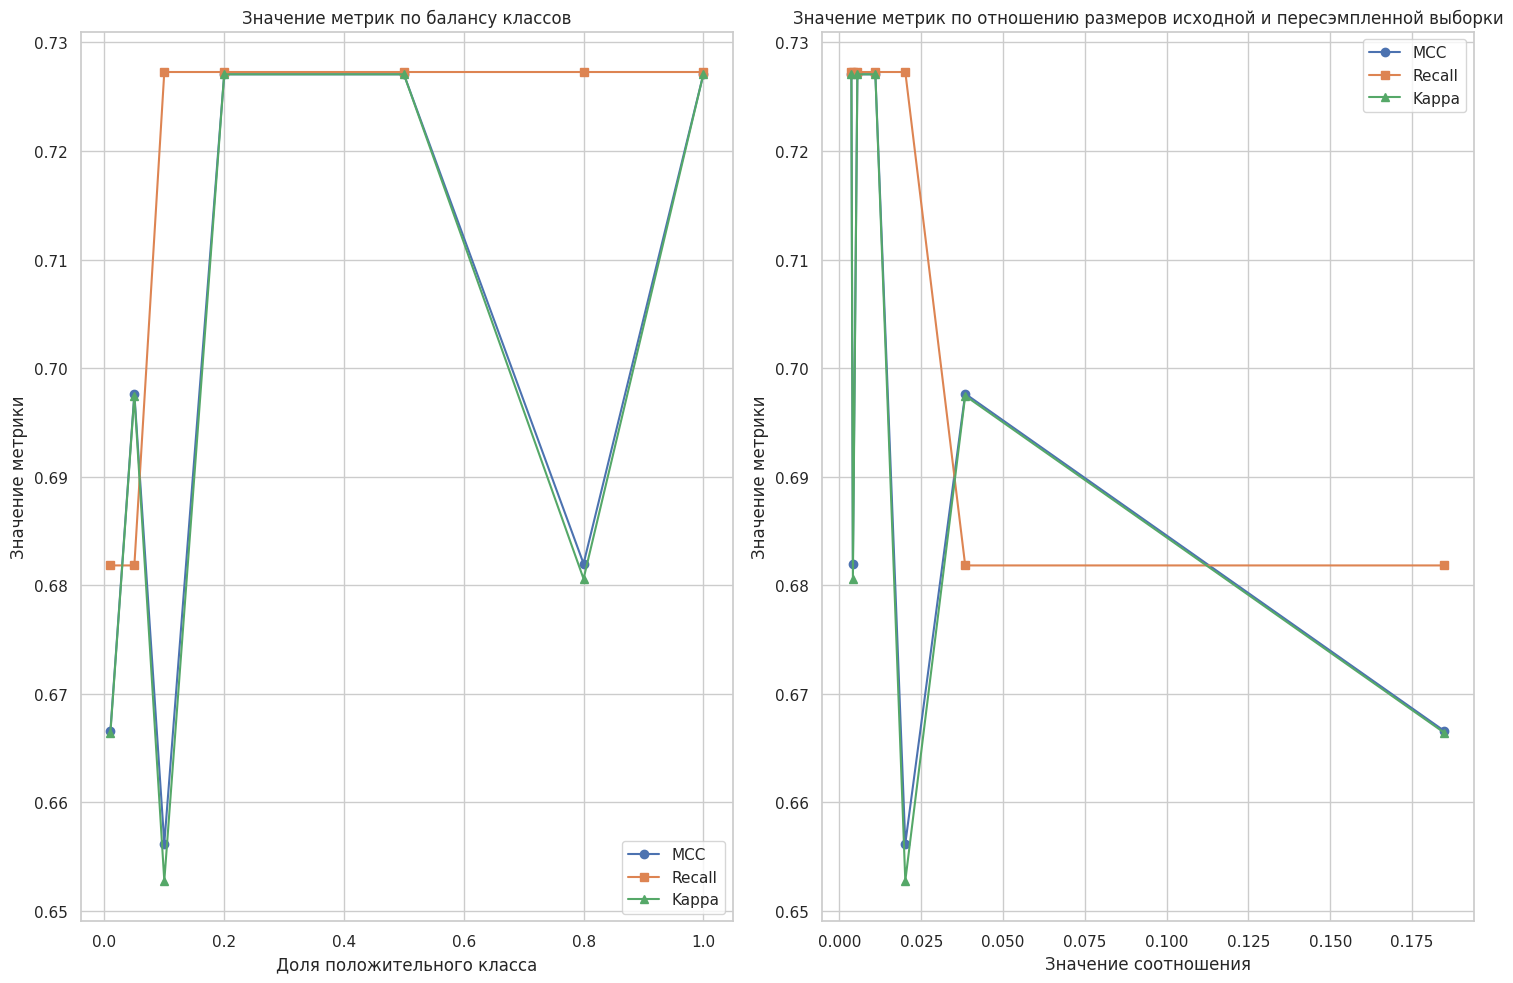

In [41]:
plt.figure(figsize=(15, 10))

plt.subplot(1, 2, 1)
plt.plot(df_under_sampler['Share'], df_under_sampler['MCC'], label='MCC', marker='o')
plt.plot(df_under_sampler['Share'], df_under_sampler['Recall'], label='Recall', marker='s')
plt.plot(df_under_sampler['Share'], df_under_sampler['Kappa'], label='Kappa', marker='^')
plt.title('Значение метрик по балансу классов')
plt.xlabel('Доля положительного класса')
plt.ylabel('Значение метрики')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(df_under_sampler['X_compr'], df_under_sampler['MCC'], label='MCC', marker='o')
plt.plot(df_under_sampler['X_compr'], df_under_sampler['Recall'], label='Recall', marker='s')
plt.plot(df_under_sampler['X_compr'], df_under_sampler['Kappa'], label='Kappa', marker='^')
plt.title('Значение метрик по отношению размеров исходной и пересэмпленной выборки')
plt.xlabel('Значение соотношения')
plt.ylabel('Значение метрики')
plt.legend()

plt.tight_layout()
plt.show()

Даже такой наивный подход может дать относительно неплохие результаты и улучшить наши метрики. Тем не менее, сейчас мы никак не используем информацию о распределении объектов в выборке. Оказывается, что даже относительно простые эвристические правила могут заметно поднять нам качество - например, мы можем при отбрасывании использовать близость отдельных объектов мажорного класса к минорному и отбрасывать самые близкие. Протестируйте алгоритм [Near-Miss](https://www.site.uottawa.ca/~nat/Workshop2003/jzhang.pdf) на наших данных и постройте графики, аналогичные предыдущему пункту (также добавьте график с зависимостью качества от числа соседей).

In [42]:
from imblearn.under_sampling import NearMiss

share_of_ones = [0.1, 0.2, 0.5]
neighbors_num = [3, 5, 7, 10]
nearmiss_results = []

for num in neighbors_num:
    for share in share_of_ones:
        print(50*'-')
        print(f'Фиттим NearMiss | Соседей: {num} | Баланс классов: {share}')
        
        near_miss = NearMiss(sampling_strategy=share, n_neighbors=num)
        
        X_res, y_res = near_miss.fit_resample(X_train_scaled, y_train)
        x_compr = len(X_res) / len(X_train_scaled)
        
        model = CatBoostClassifier(iterations=1000, 
                                   learning_rate=0.005, 
                                   depth=4, 
                                   eval_metric='PRAUC', 
                                   early_stopping_rounds=50, 
                                   random_seed=67, 
                                   verbose=False)
        
        model.fit(X_res, y_res, eval_set=(X_val_scaled, y_val))
        
        y_val_probs = model.predict_proba(X_val_scaled)[:, 1]
        precision, recall, thresholds = precision_recall_curve(y_val, y_val_probs)
        mcc_scores = [matthews_corrcoef(y_val, (y_val_probs >= t).astype(int)) for t in thresholds]
        best_thresh = thresholds[np.argmax(mcc_scores)]
        
        y_test_probs = model.predict_proba(X_test_scaled)[:, 1]
        y_test_pred = (y_test_probs >= best_thresh).astype(int)
        
        nearmiss_results.append({
            'K_neighbors': num,
            'Share': share,
            'X_compr': x_compr,
            'MCC': matthews_corrcoef(y_test, y_test_pred),
            'Recall': recall_score(y_test, y_test_pred),
            'Kappa': cohen_kappa_score(y_test, y_test_pred)
        })

df_nearmiss = pd.DataFrame(nearmiss_results)
display(df_nearmiss)

--------------------------------------------------
Фиттим NearMiss | Соседей: 3 | Баланс классов: 0.1
--------------------------------------------------
Фиттим NearMiss | Соседей: 3 | Баланс классов: 0.2
--------------------------------------------------
Фиттим NearMiss | Соседей: 3 | Баланс классов: 0.5
--------------------------------------------------
Фиттим NearMiss | Соседей: 5 | Баланс классов: 0.1
--------------------------------------------------
Фиттим NearMiss | Соседей: 5 | Баланс классов: 0.2
--------------------------------------------------
Фиттим NearMiss | Соседей: 5 | Баланс классов: 0.5
--------------------------------------------------
Фиттим NearMiss | Соседей: 7 | Баланс классов: 0.1
--------------------------------------------------
Фиттим NearMiss | Соседей: 7 | Баланс классов: 0.2
--------------------------------------------------
Фиттим NearMiss | Соседей: 7 | Баланс классов: 0.5
--------------------------------------------------
Фиттим NearMiss | Соседей: 10 |

,K_neighbors,Share,X_compr,MCC,Recall,Kappa
0,3,0.1,0.020132,0.696066,0.727273,0.695407
1,3,0.2,0.010981,0.762596,0.727273,0.761729
2,3,0.5,0.005491,0.799377,0.681818,0.789337
3,5,0.1,0.020132,0.681982,0.727273,0.680589
4,5,0.2,0.010981,0.762596,0.727273,0.761729
5,5,0.5,0.005491,0.674058,0.454545,0.624819
6,7,0.1,0.020132,0.711059,0.727273,0.710883
7,7,0.2,0.010981,0.590593,0.590909,0.590593
8,7,0.5,0.005491,0.762596,0.727273,0.761729
9,10,0.1,0.020132,0.762596,0.727273,0.761729


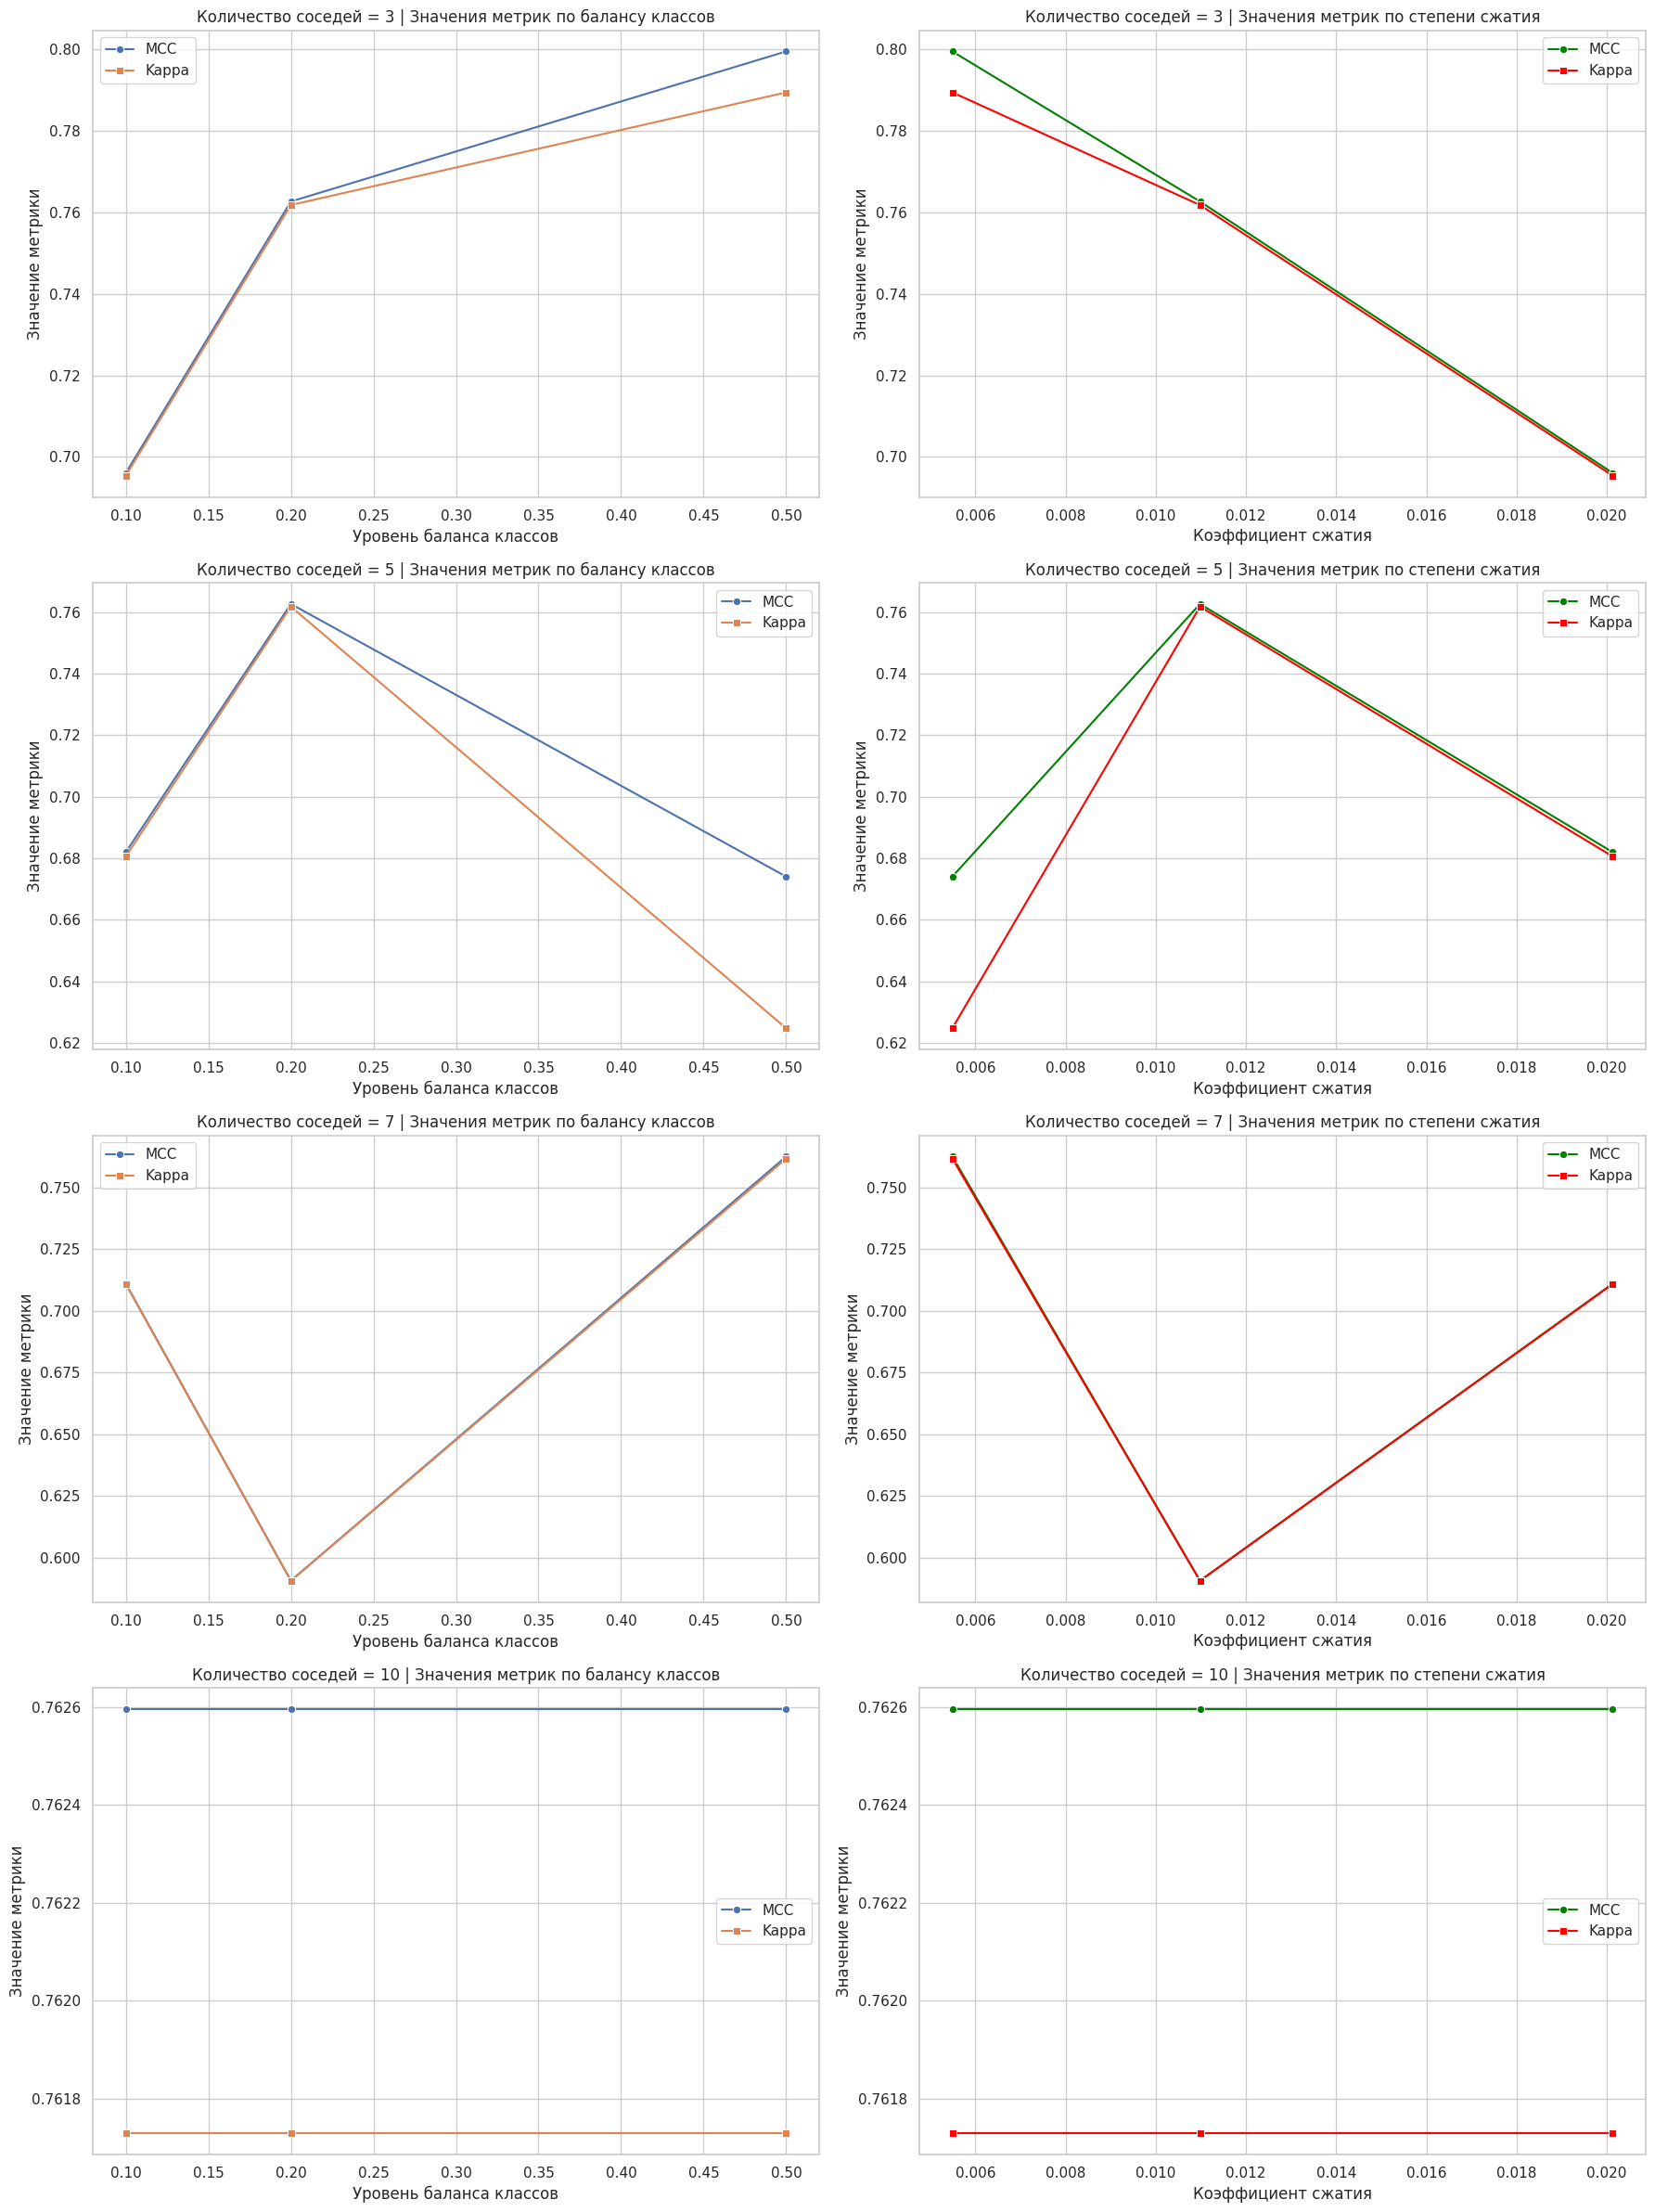

In [43]:
rows_quant = len(neighbors_num) 

fig, axes = plt.subplots(rows_quant, 2, figsize=(18, 6 * rows_quant))

axes = axes.flatten()

for i, nei_num in enumerate(neighbors_num):
    fixed_nei_df = df_nearmiss[df_nearmiss['K_neighbors'] == nei_num].sort_values('Share')
    
    ax_share = axes[2 * i]
    ax_compr = axes[2 * i + 1]
    
    sns.lineplot(data=fixed_nei_df, x='Share', y='MCC', marker='o', label='MCC', ax=ax_share)
    sns.lineplot(data=fixed_nei_df, x='Share', y='Kappa', marker='s', label='Kappa', ax=ax_share)
    ax_share.set_title(f'Количество соседей = {nei_num} | Значения метрик по балансу классов')
    ax_share.set_xlabel('Уровень баланса классов')
    ax_share.set_ylabel('Значение метрики')
    ax_share.legend()

    sns.lineplot(data=fixed_nei_df, x='X_compr', y='MCC', marker='o', label='MCC', color='green', ax=ax_compr)
    sns.lineplot(data=fixed_nei_df, x='X_compr', y='Kappa', marker='s', label='Kappa', color='red', ax=ax_compr)
    ax_compr.set_title(f'Количество соседей = {nei_num} | Значения метрик по степени сжатия')
    ax_compr.set_xlabel('Коэффициент сжатия')
    ax_compr.set_ylabel('Значение метрики')
    ax_compr.legend()

plt.tight_layout()
plt.show()

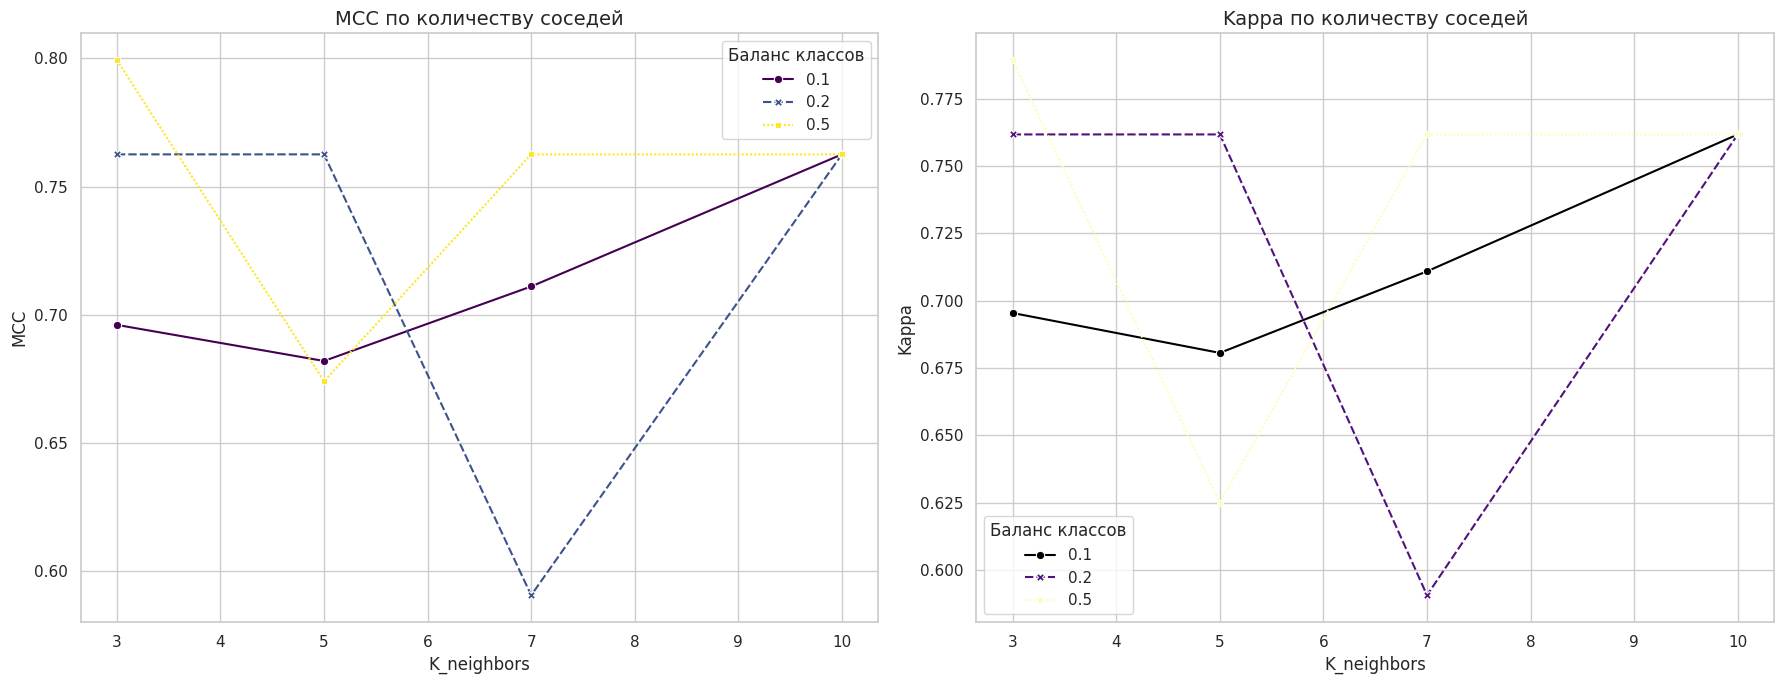

In [44]:
plt.figure(figsize=(18, 7))

ax1 = plt.subplot(1, 2, 1)
sns.lineplot(data=df_nearmiss, x='K_neighbors', y='MCC', hue='Share', style='Share', markers=True, palette='viridis', ax=ax1)
ax1.set_title('MCC по количеству соседей', fontsize=14)
ax1.legend(title='Баланс классов', loc='best')

ax2 = plt.subplot(1, 2, 2)
sns.lineplot(data=df_nearmiss, x='K_neighbors', y='Kappa', hue='Share', style='Share', markers=True, palette='magma', ax=ax2)
ax2.set_title('Kappa по количеству соседей', fontsize=14)
ax2.legend(title='Баланс классов', loc='best')

plt.tight_layout()
plt.show()

**Бонус (1 балл)**. imblearn также предлагает много различных методов для андерсэмплинга. Выберите что-нибудь еще из предлагаемого на свой вкус, опишите идею метода и протестируйте его.


В данном случае мы будем использовать TomekLinks. Работает он следующим образом: смотрит на объекты минорного класса и смотрит на их ближайших соседей. Если ближайшим соседом объекта минорного класса является объект мажорного - и для мажорного то же самое - то такая пара называется Tomek Links. Этот ближайший сосед либо находится на границе, что только запутает нашу модель, потому что у одинаковых признаков два разных класса, либо это в целом шум (нолик (мажорный) случайно попал к единицам). Поэтому мы этот объект мажорного класса удаляем. При этом, делается всего одна итерация. То есть, если второй ближайший сосед - это тоже нолик для единицы, этот нолик уже не удаляется

In [58]:
from imblearn.under_sampling import TomekLinks


print(50*'-')
print('Запускаем Томика')

tom_link = TomekLinks(sampling_strategy='auto')

X_res_tl, y_res_tl = tom_link.fit_resample(X_train_scaled, y_train)

delete_obj = len(X_train_scaled) - len(X_res_tl)
print(f'Удалено объектов мажорного класса: {delete_obj}')
print(f'Осталось данных: {len(X_res_tl)} объектов')

model_tl = CatBoostClassifier(iterations=1000, 
                              learning_rate=0.005, 
                              depth=4, 
                              eval_metric='PRAUC', 
                              early_stopping_rounds=50, 
                              random_seed=67, 
                              verbose=False
                             )

model_tl.fit(X_res_tl, y_res_tl, eval_set=(X_val_scaled, y_val))

y_val_probs_tl = model_tl.predict_proba(X_val_scaled)[:, 1]
_, _, thresholds_tl = precision_recall_curve(y_val, y_val_probs_tl)
mcc_tl = [matthews_corrcoef(y_val, (y_val_probs_tl >= t).astype(int)) for t in thresholds_tl]
best_t_tl = thresholds_tl[np.argmax(mcc_tl)]

y_test_pred_tl = (model_tl.predict_proba(X_test_scaled)[:, 1] >= best_t_tl).astype(int)

mcc_test_tl = matthews_corrcoef(y_test, y_test_pred_tl)
kappa_test_tl = cohen_kappa_score(y_test, y_test_pred_tl)

print(f'Результат Томика на тесте (с лучшим порогом {best_t_tl:.3f}):')
print(f' | MCC: {mcc_test_tl:.3f}')
print(f' | Kappa: {kappa_test_tl:.3f}')

--------------------------------------------------
Запускаем Томика
Удалено объектов мажорного класса: 14
Осталось данных: 227831 объектов
Результат Томика на тесте (с лучшим порогом 0.058):
 | MCC: 0.669
 | Kappa: 0.666


# Часть 2. Поиск аномалий. 

Как вы могли заметить, методы балансировки выборок очень часто могут привести к не самым лучшим результатам из-за того, что они по сути искажают информацию о реальном распределении данных - в реальности обычно требуется долгий подбор в принципе работоспособных для задачи методов и их аккуратная настройка. 

Теперь давайте попробуем слегка сменить постановку задачи и переключиться на задачу 'одноклассовой' классификации, то есть - поиска *аномалий* в выборке. В общем-то, это вполне согласуется с нашей областью работы - мы действительно можем назвать мошеннические транзакции аномальньми (как интуитивно, так и на основании наблюдаемой балансировки данных). 

Стоит отметить, что методы обнаружения аномалий чаще всего относятся к классу методов обучения без учителя. Это дает некоторый положительный эффект - нам не обязательно нужно тратить время на разметку данных (тем не менее, для контроля качества какую-то часть разметить все-таки придется). Впрочем, чаще всего перфоманс таких методов оказывается заметно хуже, чем у честного обучения с учителем (если мы можем себе его позволить).



**Задание 4. (3 балла).** На занятиях вы разбирали схожий с Random Forest подход для детекции аномалий без известной разметки данных, называемый Isolation Forest. Напомним суть: на этапе обучения мы создаем ансамбль из решающих деревьев, в котором признак и порог на каждую вершину подбираются случайно. Затем мы считаем для объектов оценку аномальности через длину пути до соответствующего листа в каждом дереве.

В данном задании вам предлагается реализовать модификацию данного алгоритма, известную как Extended Isolation Forest. В ней мы на каждом шаге будем определять не порог для признака, а полноценную случайную гиперплоскость, разбивающую выборку на 2 части. С детальным описанием вы можете ознакомиться [здесь](https://arxiv.org/pdf/1811.02141.pdf).

Ниже приведен шаблон кода. Постарайтесь работать в его рамках (минорные изменения вполне допустимы, главное не переворачивайте всю структуру с ног на голову). 

**NB**: будем считать, что в нашем датасете нет категориальных признаков - можете не заморачиваться с их обработкой (но в общем случае, это будет важно).

**Советы**:
 - Численные признаки лучше предобработать надлежащим образом.
 - Возможно, вам поможет выбрасывание некоторых признаков.
 - Внимательно следите за знаками.
 - Не игнорируйте документирующие строки.
 - Вероятнее всего, вы не сможете приблизиться по качеству к supervised-решениям. Если у вас не получается это сделать (но вы уверены в своей правоте), не стоит тратить слишком много времени на поиск ошибок.
- При желании, можете вынести этот код в отдельный файл и приложить его к ноутбуку. Он довольно громоздкий и в ноутбуке такое плохо читается.


**Бонусы (каждый по 0.5)**:
- Сделайте ваш EIF параллельным (`multiprocessing`, `joblib`).
- Добавьте возможность откатиться к дефолтному варианту Isolation Forest. (порассуждайте, как можно реализовать это в данной модели?):


In [56]:
def c_factor(n):
    '''
    Computes average path length for an unsuccessful search in a binary search tree.
    Params:
        n: int - number of data points for BST
    '''
    #your code here

    if n > 2:
        H = np.log(n - 1) + 0.5772
        return 2 * H - (2 * (n - 1) / n)
    elif n == 2:
        return 1.0
    else:
        return 0.0

def calc_height(X, depth, node):
    '''
    Calculates anomaly scores for sample in a recursive manner.
    Params:
        X: np.array - current sample, available to node
        
        depth: int - path length up to current node
        
        node: Node - current tree node
        
    Returns:
        scores: int, float or np.array - anomaly scores for sample
    '''
    scores = np.zeros(X.shape[0])
    
    if node.kind == 'external':
        return np.full(X.shape[0], depth + c_factor(node.size))
        
    mask_of_distrib = (X @ node.w - node.b) <= 0
    
    if np.any(mask_of_distrib):
        scores[mask_of_distrib] = calc_height(X[mask_of_distrib], depth + 1, node.left)
    if np.any(~mask_of_distrib):
        scores[~mask_of_distrib] = calc_height(X[~mask_of_distrib], depth + 1, node.right)
        
    return scores


class Node(object):
    '''
    A single node object for each tree. Contains information on height, current data,
    splitting hyperplane and children nodes.
    
    Attributes:
        X: np.array - data available to current node
        size: int - length of available data
        
        depth: int - depth of node

        left: Node - left child
        right: Node - right child

        kind: str - either 'internal' or 'external', indicates the type of current node

        w: np.array - normal vector for the splitting hyperplane
        b: float - intercept term for the splitting hyperplane
    '''
    def __init__(self, X, depth, left, right, kind, w, b):
        '''
        Node(h, left, right, kind, w, b)
        Represents the node object.
        
        Params:
            X: np.array - data available to current node
            depth: int - depth of node
            
            left: Node - left child
            right: Node - right child
            
            kind: str - either 'internal' or 'external', indicates the type of current node
            
            w: np.array - normal vector for the splitting hyperplane
            b: float - intercept term for the splitting hyperplane
            
        '''
        self.size = len(X)
        
        self.depth = depth
        
        self.left = left
        self.right = right
        
        self.kind = kind
    
        self.w = w
        self.b = b
    
    def __repr__(self):
        '''
        For convenience only.
        '''
        return f'Node(size={self.size}, depth={self.depth}, kind={self.kind})'

class RandomizedTree(object):
    '''
    Single randomized tree object. Stores root and its depth (tree is built recursively).
    Attributes:
        depth: int - current tree depth
        
        max_depth: int - maximum tree depth
        
        root: Node - root node 

        internal_count: int - number of internal nodes

        external_count: int - number of external nodes
        
    '''
    def __init__(self, X, max_depth):
        '''
        Single randomized tree object. Stores root and its depth (tree is built recursively).
        Params:
            X: np.array - train sample
            max_depth: int - maximum tree depth

        '''
        self.depth = 0
        self.max_depth = max_depth
        
        self.internal_count = 0
        self.external_count = 0

        self.root = self.grow(X, 0)
        
    def __repr__(self):
        '''
        For convenience only.
        '''
        
        return f'RandomizedTree(depth={self.depth}, max_depth={self.max_depth}, n_internal={self.internal_count}, n_external={self.external_count})'

        
        
    def grow(self, X, depth):
        '''
        Grow tree in a recursive manner.
        Params:
            X: np.array - available train sample
            
            depth: int - current tree depth
            
        Returns:
            node: Node - a trained node with separating hyperplane data.
                         Node provides access to children if necessary (these are built recursively)
        '''
        #your code here

        if depth >= self.max_depth or X.shape[0] <= 1:
            self.external_count += 1
            left = None
            right = None
            kind = 'external'
            w = None
            b = None
            return Node(X, depth, left, right, kind, w, b)

        n_features = X.shape[1]
        
        w = np.random.normal(0, 1, size=n_features)
        
        mins = X.min(axis=0)
        maxs = X.max(axis=0)
        p = np.random.uniform(mins, maxs)
        
        b = np.dot(p, w)
        
        mask = (X @ w - b) <= 0
        
        if np.all(mask) or np.all(~mask):
            self.external_count += 1
            return Node(X, depth, None, None, 'external', None, None)

        self.internal_count += 1
        self.depth = max(self.depth, depth)
        
        left = self.grow(X[mask], depth + 1)
        right = self.grow(X[~mask], depth + 1)
        kind = 'internal'
            
        return Node(X, depth, left, right, kind, w, b)

    def score_samples(self, X):
        '''
        Calculate anomaly scores for given data. You may utilize outer function `calc_height`.
        Params:
            X: np.array - data to be evaluated
            
        Returns:
            scores: np.array - estimated anomaly scores
        '''
        scores = calc_height(X, 0, self.root)

        return scores
        
    
class ExtendedIsolationForest(object):
    '''
    Extended Isolation Forest object. Stores training data and trained randomized trees.
    Attributes:
        n_trees: int - number of Randomized Trees
        
        max_depth: int - maximum depth of each tree
        
        subsample_rate: float - draw `subsample_rate * X.shape[0]` samples for each tree
        
        trees: list - container for trained trees 
        
        contamination: float - estimated fraction of anomaly samples in data. Used for thresholding
        
    '''
    
    def __init__(self, n_trees, subsample_rate, max_depth=None, contamination=0.01):
        '''
        Extended Isolation Forest object. Stores training data and trained randomized trees.
        Params:
            n_trees: int - number of Randomized Trees

            subsample_rate: float - draw `subsample_rate * X.shape[0]` samples for each tree

            max_depth: int or None - maximum depth of each tree. Defaults to ceil(log_2(subsample_size)) if not provided

            contamination: float - estimated fraction of anomaly samples in data. Used for thresholding

        '''
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.subsample_rate = subsample_rate
        self.trees = []
        self.contamination = contamination
        self.is_fit = False
        
    def __repr__(self):
        '''For convenience only.'''
        
        return f'ExtendedIsolationForest(n_trees={self.n_trees}, max_depth={self.max_depth}, subsample_rate={self.subsample_rate}, contamination={self.contamination}, is_fit={self.is_fit})'
        
    def fit(self, X):
        '''
        Fit EIF to new data.
        Params:
            X: np.array - 2d array of samples
        '''
        self.n_train_samples = X.shape[0]
        subsample_size = int(self.subsample_rate * self.n_train_samples)
        
        if self.max_depth is None:
            self.max_depth = int(np.ceil(np.log2(subsample_size)))

        for _ in range(self.n_trees):
            indices = np.random.choice(self.n_train_samples, subsample_size, replace=False)
            tree = RandomizedTree(X[indices], self.max_depth)
            self.trees.append(tree)
            
        self.is_fit = True
        return self
    
    def score_samples(self, X):
        '''
        Estimate (normalized) anomaly score for each given sample
        Params:
            X: np.array - new samples

        Returns:
            scores: np.array - anomaly scores (larger value means higher probability of a sample being an outlier)
        '''
        
        all_heights_among_trees = np.array([tree.score_samples(X) for tree in self.trees]).T

        avg_heights_obj = np.mean(all_heights_among_trees, axis=1)
        
        subsample_size = int(self.subsample_rate * self.n_train_samples)
        c = c_factor(subsample_size)
        
        scores = 2**(-avg_heights_obj / c)

        return scores

    
    def predict(self, X):
        '''
        Predict if given samples are outliers.
        Params:
            X: np.array - new samples

        Returns:
            labels: np.array - anomaly labels (1 for outliers, 0 for inliers)
        '''
        scores = self.score_samples(X)
        
        threshold = np.percentile(scores, 100 * (1 - self.contamination))
        
        labels = (scores >= threshold).astype(int)

        return labels


**Задание 5. (1 балл).** Протестируйте вашу реализацию EIF и подберите оптимальные гиперпараметры (наш метод не использует разметку, поэтому можете попробовать делать это на обучающей выборке). Сравните ее с обычным IF из `sklearn` (желательно делать это на одних и тех же параметрах). Удалось ли сделать лучше?

In [66]:
def evaluate_model(y_true, y_pred, name):
    mcc = matthews_corrcoef(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    print(f'{name}:')
    print(f' MCC: {mcc:.3f}')
    print(f' Kappa: {kappa:.3f}')
    return mcc, kappa

In [69]:
#your code here
from sklearn.ensemble import IsolationForest
sub_rate = 256 / len(X_train_scaled) 
contam = y_train.mean()

tree_quantities = [50, 100, 150, 200]

results = []

for n_trees in tree_quantities:

    print(50 * '-')
    print(f'Обучаем наш Extended Isolation Forest с количеством деревьев {n_trees}')
    my_eif = ExtendedIsolationForest(n_trees=n_trees, subsample_rate=sub_rate)
    my_eif.fit(X_train_scaled)

    y_pred_train = my_eif.predict(X_train_scaled)
    y_pred_val = my_eif.predict(X_val_scaled)

    mcc_train = matthews_corrcoef(y_train, y_pred_train)
    mcc_val = matthews_corrcoef(y_val, y_pred_val)

    results.append({'n_trees': n_trees, 'mcc_train': mcc_train, 'mcc_val': mcc_val})

best_n_trees = sorted(results, key=lambda x: x['mcc_train'])[-1]['n_trees']
print(f'Оптимальное количество деревьев: {best_n_trees}')

print(f'Обучаем наш Extended Isolation Forest с лучшим количеством деревьев {best_n_trees}')
my_eif = ExtendedIsolationForest(n_trees=best_n_trees, subsample_rate=sub_rate)
my_eif.fit(X_train_scaled)
y_pred_eif = my_eif.predict(X_test_scaled)

print('Обучаем Isolation Forest из sklearn')
sk_if = IsolationForest(n_estimators=best_n_trees, 
                        max_samples=256, 
                        random_state=67)
sk_if.fit(X_train_scaled)
y_pred_sk = (sk_if.predict(X_test_scaled) == -1).astype(int)

evaluate_model(y_test, y_pred_eif, name='Наш слон EIF')
print('-' * 50)
evaluate_model(y_test, y_pred_sk, name='Не наш слон IF')

--------------------------------------------------
Обучаем наш Extended Isolation Forest с количеством деревьев 50
--------------------------------------------------
Обучаем наш Extended Isolation Forest с количеством деревьев 100
--------------------------------------------------
Обучаем наш Extended Isolation Forest с количеством деревьев 150
--------------------------------------------------
Обучаем наш Extended Isolation Forest с количеством деревьев 200
Оптимальное количество деревьев: 200
Обучаем наш Extended Isolation Forest с лучшим количеством деревьев 200
Обучаем Isolation Forest из sklearn
Наш слон EIF:
 MCC: 0.124
 Kappa: 0.064
--------------------------------------------------
Не наш слон IF:
 MCC: 0.110
 Kappa: 0.031


(np.float64(0.10952138316651357), np.float64(0.030761346167454184))

Возможно, ваш алгоритм выдал большие оценки объектам с негативной разметкой. Постарайтесь выбрать несколько таких объектов и доступно объяснить (= с кодом и графиками), почему так вышло:

In [ ]:
#your code here

**Задание 6. (1 балл).** `sklearn` также предлагает нам и другие методы для поиска аномалий. В этом задании мы предлагаем вам сделать следующее:

Для начала попробуйте использовать методы Local Outlier Factor и One-Class SVM. Сравните результаты с IF и EIF.  

In [ ]:
#your code here

У вас началась депрессия из-за плохих метрик? Не беда! Сейчас давайте сделаем так: все методы, опробованные в этой части, попробуем задействовать для создания дополнительных признаков в данных. Проделайте это (не забудьте, что обучаться здесь нужно на трейне). Теперь возьмите лучшую модель из предыдущей части и обучите на новых данных. Смогли ли unsupervised-методы повысить вам качество?

In [ ]:
#your code here

**Бонус. (0.1 балла).**

При сдаче проверяющий запустит следующую клетку один раз. Если она даст положительный результат, вы получите 0.1 бонусных балла. Если она даст отрицательный результат, вы получите -0.1 бонусных балла. 

Если вы хотите отказаться от сдачи данного задания, допишите 'хочу' после двоеточия: `your text here`

Ниже вы можете попрактиковаться и оценить ваши силы (изменять код ячейки запрещается!)

In [55]:
import random

rng = random.SystemRandom(0)
rng.uniform(-1.0, 1.0)

0.041391348318236876